# 

# 

**PROYECTO METODOS  NUMERICOS FINAL**

In [1]:
import pandas as pd
ruta = r"C:\Users\PERSONAL\Desktop\PROYECTO FINAL METODOS NUMERICOS\train.csv"
df = pd.read_csv(ruta, sep=";")
df.head()

,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500
1,2,9600,6,1976,978,1262,1262,1262,2,2,460,181500
2,3,11250,7,2001,486,920,920,1786,2,2,608,223500
3,4,9550,7,1915,216,756,961,1717,1,3,642,140000
4,5,14260,8,2000,655,1145,1145,2198,2,3,836,250000


**CREACION YA DE LA PREDICCION GENERAL**

In [2]:
# Separación de variables independientes (X) y variable dependiente (y)

# X contiene las características de las viviendas (variables explicativas)
X = df.drop("SalePrice", axis=1)

# y contiene el valor real del precio de venta (variable objetivo)
y = df["SalePrice"]

# Visualización de las primeras filas para verificar la correcta separación
print("Variables independientes (X):")
display(X.head())

print("Variable dependiente (y):")
display(y.head().to_frame())


Variables independientes (X):


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,1,8450,7,2003,706,856,856,1710,2,2,548
1,2,9600,6,1976,978,1262,1262,1262,2,2,460
2,3,11250,7,2001,486,920,920,1786,2,2,608
3,4,9550,7,1915,216,756,961,1717,1,3,642
4,5,14260,8,2000,655,1145,1145,2198,2,3,836


Variable dependiente (y):


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [3]:
import numpy as np

# PREPARACIÓN DE LOS DATOS PARA EL MODELO NUMÉRICO

# Se elimina la columna Id porque solo identifica registros y no aporta información matemática al modelo

X_modelo = X.drop("Id", axis=1)

# Conversión de los datos a arreglos numéricos (forma matricial)
matriz_A = X_modelo.values
vector_b = y.values



# APLICACIÓN DEL MÉTODO DE MÍNIMOS CUADRADOS (Construcción y resolución de la ecuación normal)

# Se calcula la transpuesta de la matriz A
matriz_AT = matriz_A.T

# Se construyen los términos de la ecuación normal:
# (AᵀA)x = Aᵀb

matriz_ATA = np.dot(matriz_AT, matriz_A)
vector_ATb = np.dot(matriz_AT, vector_b)

# Se resuelve el sistema lineal para obtener los coeficientes del modelo
coeficientes_modelo = np.linalg.solve(matriz_ATA, vector_ATb)


# PREDICCIÓN DE LOS PRECIOS DE LAS VIVIENDAS

# Se calculan los valores estimados utilizando el modelo obtenido
precios_estimados = np.dot(matriz_A, coeficientes_modelo)

**GRAFICA PREDICCION GENERAL SIN NORMALIZAR**

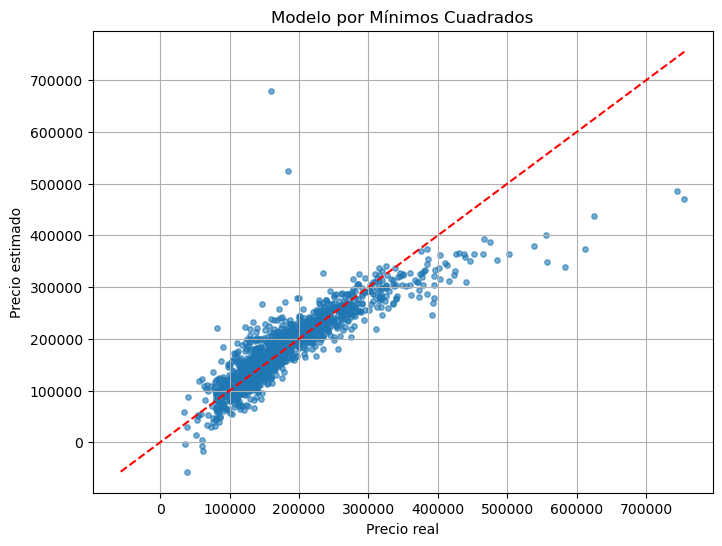

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y, precios_estimados, alpha=0.6, s=15)

min_val = min(y.min(), precios_estimados.min())
max_val = max(y.max(), precios_estimados.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Precio real")
plt.ylabel("Precio estimado")
plt.title("Modelo por Mínimos Cuadrados")
plt.grid(True)
plt.show()


**PREDICCION MEDIANTE ID ESCODIGO**

In [5]:
# ============================================================
# SELECCIÓN DE UNA VIVIENDA ESPECÍFICA PARA EVALUACIÓN
# ============================================================

# Ingresar el ID de la vivienda que se desea analizar
id_vivienda = int(input("Ingrese el ID de la vivienda que desea analizar: "))

# Buscar la fila correspondiente a ese ID
fila_casa = df[df["Id"] == id_vivienda]

if fila_casa.empty:
    print("No se encontró una vivienda con ese ID.")
else:
    print("\nDatos de la vivienda seleccionada:")
    display(fila_casa)

    # Índice real dentro del dataset
    indice_real = fila_casa.index[0]

    # Precio real
    precio_real = y.iloc[indice_real]

    # Precio estimado por el modelo
    precio_estimado = precios_estimados[indice_real]

    # Error absoluto
    error_absoluto = abs(precio_real - precio_estimado)

    # Error porcentual
    error_porcentual = (error_absoluto / precio_real) * 100

    print("\nRESULTADOS DE LA PREDICCIÓN")
    print("----------------------------------")
    print(f"Precio real:      ${precio_real:,.2f}")
    print(f"Precio estimado:  ${precio_estimado:,.2f}")
    print(f"Error absoluto:   ${error_absoluto:,.2f}")
    print(f"Error porcentual: {error_porcentual:.2f}%")



Ingrese el ID de la vivienda que desea analizar:  1



Datos de la vivienda seleccionada:


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN
----------------------------------
Precio real:      $208,500.00
Precio estimado:  $215,750.49
Error absoluto:   $7,250.49
Error porcentual: 3.48%


**Grafica comparativa mediante el ID**

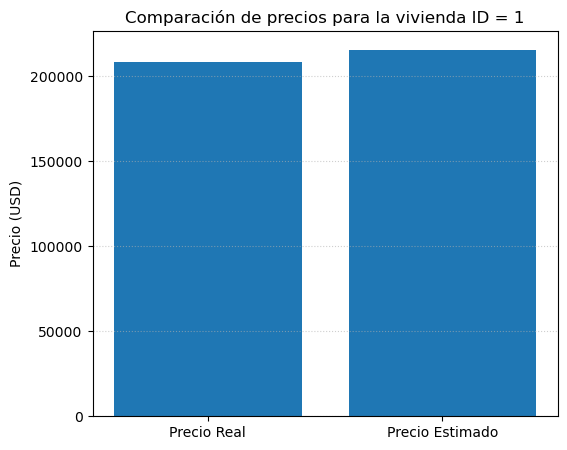

In [6]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA COMPARATIVA PARA LA VIVIENDA SELECCIONADA
# ============================================================

valores = [precio_real, precio_estimado]
etiquetas = ["Precio Real", "Precio Estimado"]

plt.figure(figsize=(6,5))
plt.bar(etiquetas, valores)
plt.title(f"Comparación de precios para la vivienda ID = {id_vivienda}")
plt.ylabel("Precio (USD)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()


**Variables más importantes**

In [7]:
# ============================================================
# ANÁLISIS DE LA INFLUENCIA DE LAS VARIABLES EN EL MODELO
# ============================================================

# Nombres de las variables utilizadas en el modelo
nombres_variables = X_modelo.columns

# Los coeficientes obtenidos representan el peso de cada variable
coeficientes = coeficientes_modelo

# Se calcula el valor absoluto para medir la magnitud de influencia
influencia = np.abs(coeficientes)

# Se crea una tabla resumen para visualizar resultados
tabla_influencia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Influencia (|coeficiente|)": influencia
})

# Se ordena de mayor a menor influencia
tabla_influencia = tabla_influencia.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA")
print("--------------------------------------------------------")
display(tabla_influencia)



INFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA
--------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,24810.712608,24810.712608
8,GarageCars,16082.351816,16082.351816
7,FullBath,5536.209545,5536.209545
2,YearBuilt,-53.829519,53.829519
6,GrLivArea,38.571145,38.571145
3,BsmtFinSF1,21.779537,21.779537
4,TotalBsmtSF,13.821910,13.821910
9,GarageArea,6.926318,6.926318
5,1stFlrSF,6.413862,6.413862
0,LotArea,0.498042,0.498042


**Grafica de variables mas importantes**

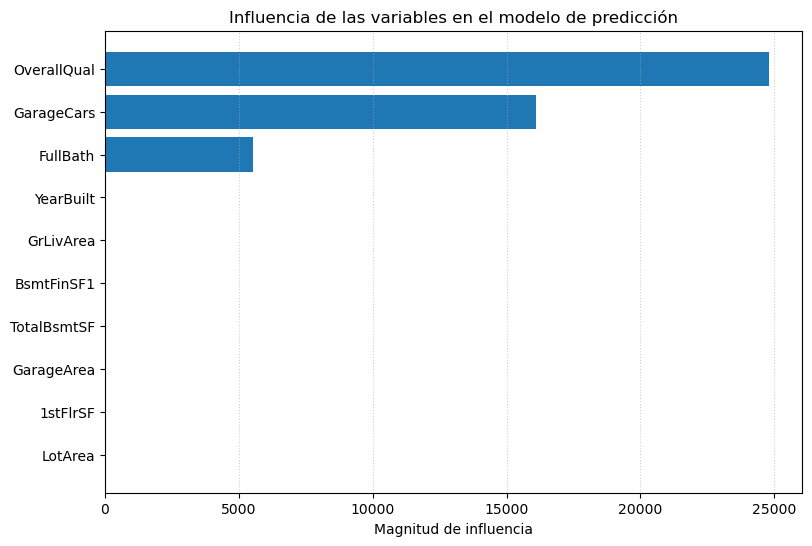

In [8]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA DE INFLUENCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9,6))

plt.barh(
    tabla_influencia["Variable"],
    tabla_influencia["Influencia (|coeficiente|)"]
)

plt.xlabel("Magnitud de influencia")
plt.title("Influencia de las variables en el modelo de predicción")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.show()


**Tabla de 10 peores predicciones sin normalizar**

In [9]:
import pandas as pd
import numpy as np

# ============================================================
# TOP 10 PEORES PREDICCIONES — MODELO SIN NORMALIZAR 
# ============================================================

tabla_resultados = pd.DataFrame({
    "ID": df["Id"],
    "Precio_Real": y.values,
    "Precio_Estimado": precios_estimados
})

tabla_resultados["Error"] = (
    tabla_resultados["Precio_Real"] -
    tabla_resultados["Precio_Estimado"]
)

tabla_resultados["Error_Absoluto"] = np.abs(
    tabla_resultados["Error"]
)

tabla_resultados["Error_Porcentual (%)"] = (
    tabla_resultados["Error_Absoluto"] /
    tabla_resultados["Precio_Real"]
) * 100


top_peores = tabla_resultados.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES (MAYOR ERROR)")
print("-----------------------------------------")

display(top_peores[[
    "ID",
    "Precio_Real",
    "Precio_Estimado",
    "Error",
    "Error_Absoluto",
    "Error_Porcentual (%)"
]])


TOP 10 PEORES PREDICCIONES (MAYOR ERROR)
-----------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1298,1299,160000,679982.319428,-519982.319428,519982.319428,324.988950
523,524,184750,524098.605985,-339348.605985,339348.605985,183.679895
691,692,755000,469733.295132,285266.704868,285266.704868,37.783670
1182,1183,745000,485806.569574,259193.430426,259193.430426,34.791064
803,804,582933,337982.168821,244950.831179,244950.831179,42.020409
898,899,611657,372789.403802,238867.596198,238867.596198,39.052540
1046,1047,556581,349338.508135,207242.491865,207242.491865,37.234920
1169,1170,625000,437498.268134,187501.731866,187501.731866,30.000277
769,770,538000,378953.316960,159046.683040,159046.683040,29.562580
440,441,555000,400980.116352,154019.883648,154019.883648,27.751330


**GRAFICAS DE LAS 10 PEORES PREDICCIONES SIN NORMALIZAR**

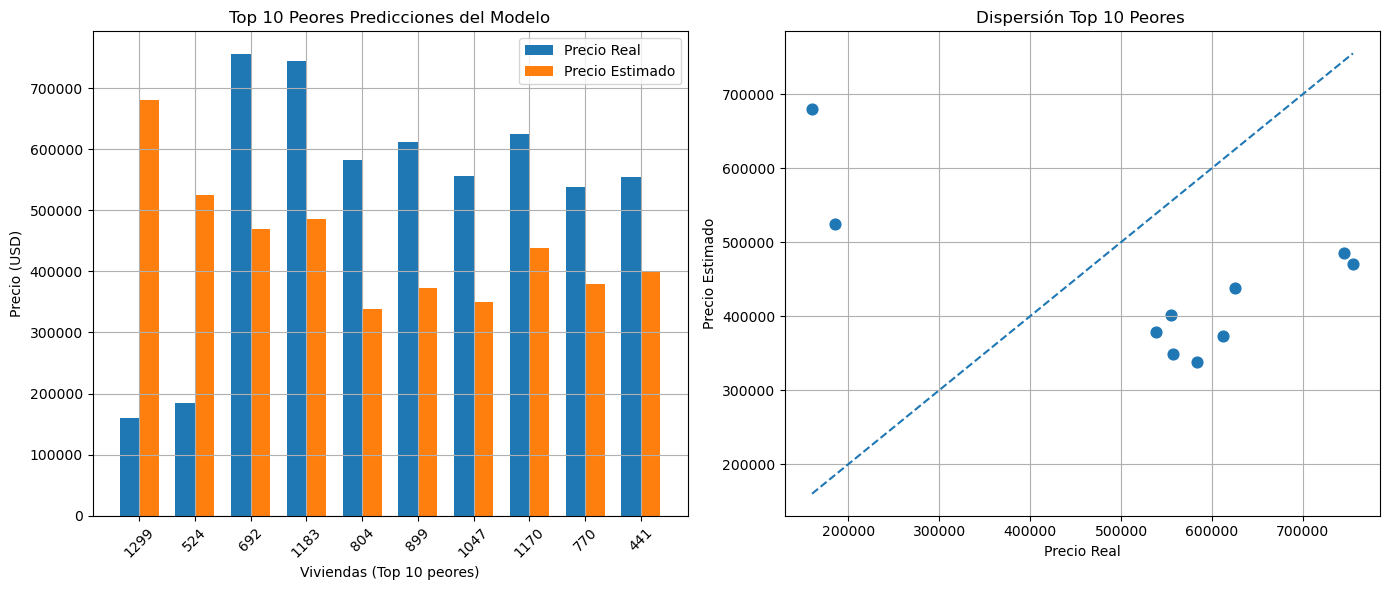

In [10]:
import matplotlib.pyplot as plt
import numpy as np

ids = top_peores["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS (IZQUIERDA)
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids))
width = 0.35

plt.bar(x - width/2, top_peores["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_peores["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("Viviendas (Top 10 peores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores Predicciones del Modelo")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN (DERECHA)
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_peores["Precio_Real"],
    top_peores["Precio_Estimado"],
    s=60
)

min_val = min(
    top_peores["Precio_Real"].min(),
    top_peores["Precio_Estimado"].min()
)

max_val = max(
    top_peores["Precio_Real"].max(),
    top_peores["Precio_Estimado"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Peores ")
plt.grid(True)
plt.tight_layout()
plt.show()

**Tabla de 10 mejores predicciones sin normalizar**

In [11]:
top_mejores = tabla_resultados.sort_values(
    by="Error_Absoluto",
    ascending=True
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES (MENOR ERROR)")
print("-----------------------------------------")

display(top_mejores[[
    "ID",
    "Precio_Real",
    "Precio_Estimado",
    "Error",
    "Error_Absoluto",
    "Error_Porcentual (%)"
]])


TOP 10 MEJORES PREDICCIONES (MENOR ERROR)
-----------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
83,84,126500,126499.607491,0.392509,0.392509,0.000310
922,923,169990,170021.146484,-31.146484,31.146484,0.018323
741,742,142000,142041.161441,-41.161441,41.161441,0.028987
356,357,173000,172949.231821,50.768179,50.768179,0.029346
1203,1204,213000,213088.026225,-88.026225,88.026225,0.041327
994,995,337500,337399.389100,100.610900,100.610900,0.029811
924,925,207500,207618.480033,-118.480033,118.480033,0.057099
1206,1207,107000,107224.153036,-224.153036,224.153036,0.209489
1207,1208,200000,199726.409376,273.590624,273.590624,0.136795
1032,1033,310000,309683.755983,316.244017,316.244017,0.102014


**GRAFICAS DE LAS 10 MEJORES PREDICCIONES SIN NORMALIZAR**

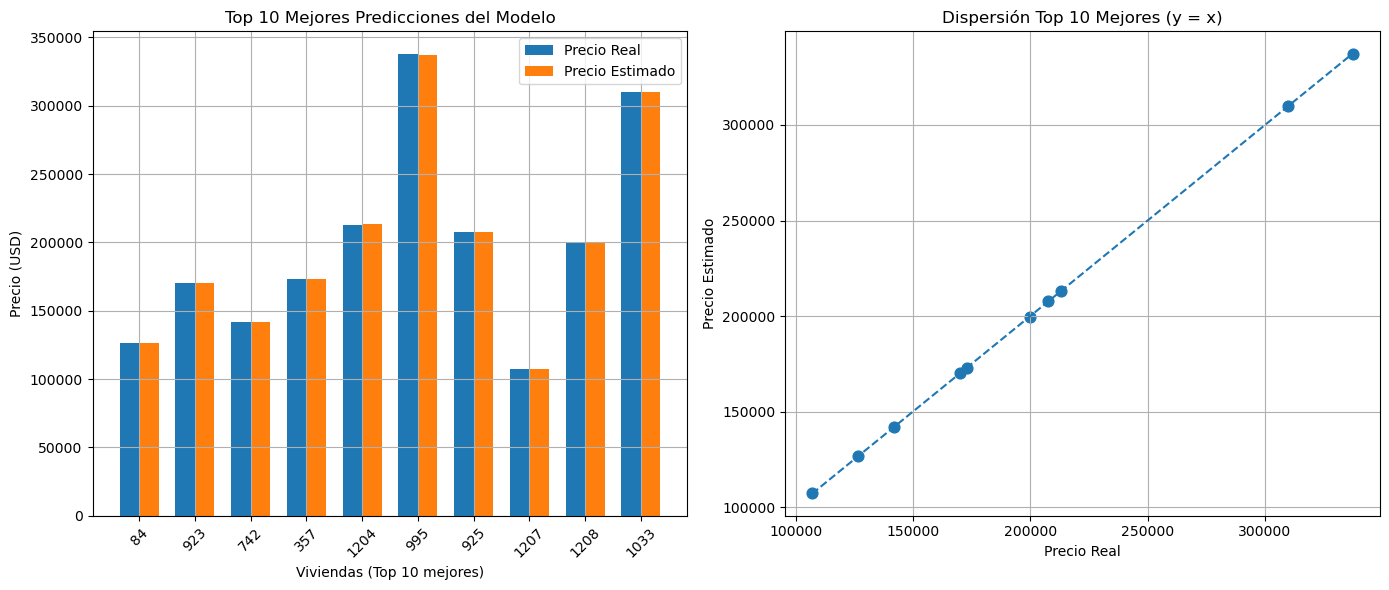

In [12]:
import matplotlib.pyplot as plt
import numpy as np

ids = top_mejores["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS (IZQUIERDA)
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids))
width = 0.35

plt.bar(x - width/2, top_mejores["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_mejores["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("Viviendas (Top 10 mejores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores Predicciones del Modelo")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN (DERECHA)
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_mejores["Precio_Real"],
    top_mejores["Precio_Estimado"],
    s=60
)

min_val = min(
    top_mejores["Precio_Real"].min(),
    top_mejores["Precio_Estimado"].min()
)

max_val = max(
    top_mejores["Precio_Real"].max(),
    top_mejores["Precio_Estimado"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Mejores (y = x)")
plt.grid(True)


plt.tight_layout()
plt.show()

**RMSE SIN NORMALIZAR**

In [13]:
import numpy as np

# ============================================
# RMSE — MODELO SIN NORMALIZAR
# ============================================

# Cálculo de residuos (error por vivienda)
residuos = y.values - precios_estimados

# Error Cuadrático Medio (MSE)
MSE = np.mean(residuos ** 2)

# Raíz del Error Cuadrático Medio (RMSE)
RMSE = np.sqrt(MSE)

print("\nEVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR")
print("----------------------------------------")
print(f"MSE: {MSE:,.2f}")
print(f"RMSE: {RMSE:,.2f} USD")



EVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR
----------------------------------------
MSE: 1,421,205,466.70
RMSE: 37,698.88 USD


**GRAFICA DEL RMSE**

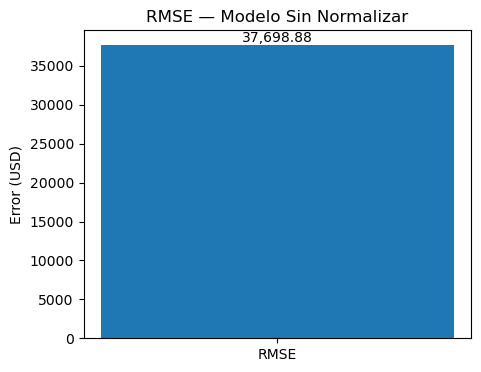

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

bars = plt.bar(["RMSE"], [RMSE])

plt.ylabel("Error (USD)")
plt.title("RMSE — Modelo Sin Normalizar")

# Mostrar valor arriba de la barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.2f}",
        ha='center',
        va='bottom'
    )

# Quitar cuadrícula
plt.grid(False)

plt.show()

**Distribucion de errores**

Text(0.5, 0, 'Error (Precio real - Precio estimado)')

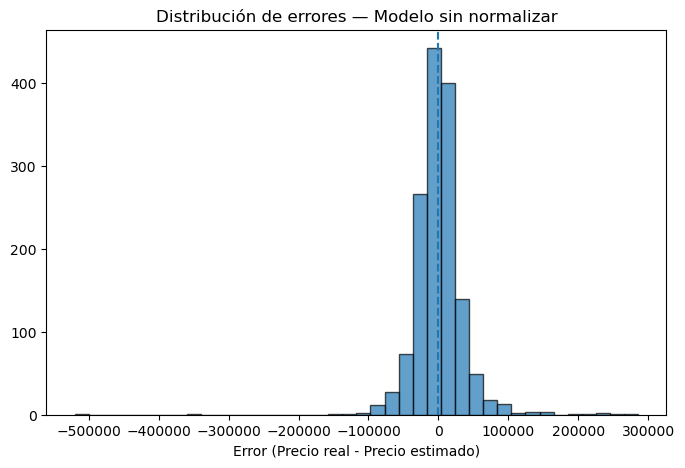

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# DISTRIBUCIÓN DE ERRORES — MODELO SIN NORMALIZAR
# ============================================

# Cálculo de residuos
errores = y.values - precios_estimados

plt.figure(figsize=(8, 5))

plt.hist(errores, bins=40, edgecolor='black', alpha=0.7)

# Línea vertical en cero (error ideal)
plt.axvline(0, linestyle='--')

plt.title("Distribución de errores — Modelo sin normalizar")
plt.xlabel("Error (Precio real - Precio estimado)")


**Tabla de errores por vivienda sin normalizar**

In [16]:
import pandas as pd
import numpy as np

# ============================================
# TABLA DE ERRORES POR VIVIENDA (SIN NORMALIZAR)
# ============================================

# Precio real
precio_real = y.values

# Precio estimado (modelo sin normalizar)
precio_estimado = precios_estimados

# Error (residuo)
error = precio_real - precio_estimado

# Error absoluto
error_abs = np.abs(error)

# Error porcentual
error_pct = (error_abs / precio_real) * 100

# Construcción de la tabla
tabla_errores_sin_norm = pd.DataFrame({
    "Id": df["Id"],
    "Precio_Real": precio_real,
    "Precio_Estimado": precio_estimado,
    "Error": error,
    "Error_Absoluto": error_abs,
    "Error_Porcentual (%)": error_pct
})

print("\nTABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)")
print("-----------------------------------------------------")

display(tabla_errores_sin_norm.head())


TABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)
-----------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,215750.493884,-7250.493884,7250.493884,3.477455
1,2,181500,189216.294906,-7716.294906,7716.294906,4.251402
2,3,223500,217103.247690,6396.752310,6396.752310,2.862082
3,4,140000,221121.843064,-81121.843064,81121.843064,57.944174
4,5,250000,285253.550739,-35253.550739,35253.550739,14.101420


**Grafica de errores por vivienda**

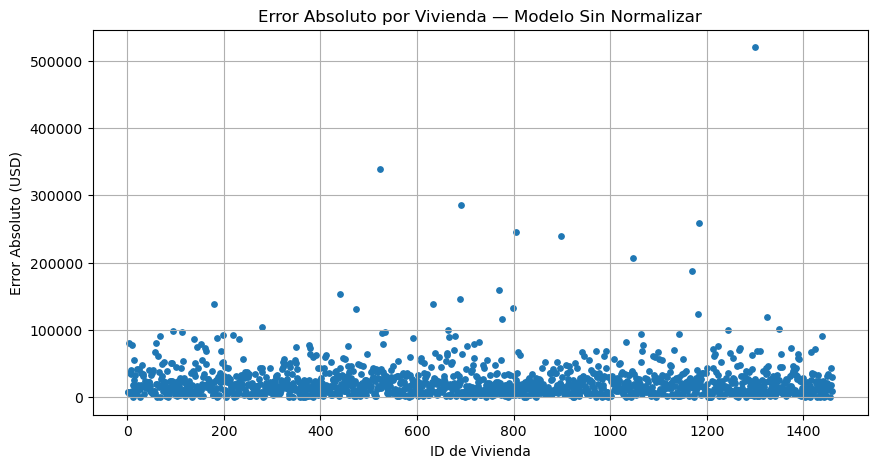

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    tabla_errores_sin_norm["Id"],
    tabla_errores_sin_norm["Error_Absoluto"],
    s=15
)

plt.xlabel("ID de Vivienda")
plt.ylabel("Error Absoluto (USD)")
plt.title("Error Absoluto por Vivienda — Modelo Sin Normalizar")

plt.grid(True)
plt.show()


**MODELO NORMALIZADO**

**Normalizacion y creación para la prediccion**

In [18]:
import pandas as pd
import numpy as np

# ===============================
# CARGA DE DATOS
# ===============================

df = pd.read_csv(r"C:\Users\PERSONAL\Desktop\PROYECTO FINAL METODOS NUMERICOS\train.csv", sep=";")

print("\n===============================")
print("DATOS CARGADOS")
print("===============================")
display(df.head())


# ===============================
# SEPARACIÓN DE VARIABLES
# ===============================

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X = X.drop("Id", axis=1)

print("\n===============================")
print("COLUMNAS DEL MODELO")
print("===============================")
print(X.columns.tolist())


# ===============================
# NORMALIZACIÓN
# ===============================

media_X = X.mean()
std_X = X.std()

X_norm = (X - media_X) / std_X

print("\n===============================")
print("PRIMERAS FILAS NORMALIZADAS")
print("===============================")
display(X_norm.head())


# ===============================
# MATRIZ DEL MODELO
# ===============================

n = X_norm.shape[0]

columna_unos = np.ones((n, 1))
A_norm = np.hstack((columna_unos, X_norm.values))

b = y.values

print("\n===============================")
print("DIMENSIÓN DE LA MATRIZ A")
print("===============================")
print(A_norm.shape)


# ===============================
# MÍNIMOS CUADRADOS
# ===============================

AT = A_norm.T

ATA = np.dot(AT, A_norm)
ATb = np.dot(AT, b)

coeficientes_norm = np.linalg.solve(ATA, ATb)

print("\n===============================")
print("COEFICIENTES DEL MODELO")
print("===============================")
print(coeficientes_norm)


# ===============================
# PREDICCIÓN
# ===============================

y_pred_norm = np.dot(A_norm, coeficientes_norm)

print("\n===============================")
print("PRIMERAS 5 PREDICCIONES")
print("===============================")
print(y_pred_norm[:5])

print("\n===============================")
print("PRIMEROS 5 VALORES REALES")
print("===============================")
print(y.values[:5])



DATOS CARGADOS


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500
1,2,9600,6,1976,978,1262,1262,1262,2,2,460,181500
2,3,11250,7,2001,486,920,920,1786,2,2,608,223500
3,4,9550,7,1915,216,756,961,1717,1,3,642,140000
4,5,14260,8,2000,655,1145,1145,2198,2,3,836,250000



COLUMNAS DEL MODELO
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

PRIMERAS FILAS NORMALIZADAS


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,-0.207071,0.651256,1.050634,0.575228,-0.459145,-0.793162,0.370207,0.789470,0.311618,0.350880
1,-0.091855,-0.071812,0.156680,1.171591,0.466305,0.257052,-0.482347,0.789470,0.311618,-0.060710
2,0.073455,0.651256,0.984415,0.092875,-0.313261,-0.627611,0.514836,0.789470,0.311618,0.631510
3,-0.096864,0.651256,-1.862993,-0.499103,-0.687089,-0.521555,0.383528,-1.025689,1.649742,0.790533
4,0.375020,1.374324,0.951306,0.463410,0.199611,-0.045596,1.298881,0.789470,1.649742,1.697903



DIMENSIÓN DE LA MATRIZ A
(1460, 11)

COEFICIENTES DEL MODELO
[180921.19589041   5489.89163307  30539.19917069   9205.37883809
   8489.61515631   4117.05601756   3884.08836123  24888.46720654
  -1040.50647208   9028.5153973    1318.78481358]

PRIMERAS 5 PREDICCIONES
[220925.75382087 182437.79372205 222974.57868018 200586.88094912
 286926.35740752]

PRIMEROS 5 VALORES REALES
[208500 181500 223500 140000 250000]


**GRAFICA DE LA PREDICCION NORMALIZADA**

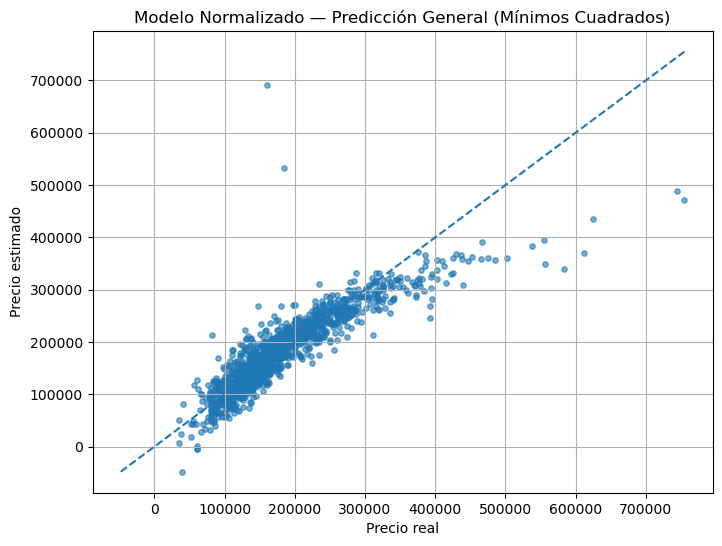

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y, y_pred_norm, alpha=0.6, s=15)

# Línea ideal y = x
min_val = min(y.min(), y_pred_norm.min())
max_val = max(y.max(), y_pred_norm.max())

plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Precio real")
plt.ylabel("Precio estimado")
plt.title("Modelo Normalizado — Predicción General (Mínimos Cuadrados)")
plt.grid(True)
plt.show()


**PREDICCION MEDIANTE ID NORMALIZADA**

In [20]:
import numpy as np

# ============================================================
# PREDICCIÓN INDIVIDUAL (MODELO NORMALIZADO) — SIN GRÁFICA
# ============================================================

# Ingreso del ID
id_usuario = int(input("Ingrese el ID de la vivienda que desea analizar: "))

# Buscar vivienda
vivienda = df[df["Id"] == id_usuario]

if vivienda.empty:
    print(" ID no encontrado en el dataset")

else:
    print("\nDatos originales de la vivienda seleccionada:")
    display(vivienda)

    # Preparar datos
    X_vivienda = vivienda.drop(["SalePrice", "Id"], axis=1)

    # Normalización con parámetros del modelo
    X_vivienda_norm = (X_vivienda - media_X) / std_X

    # Convertir a vector NumPy
    fila = X_vivienda_norm.values

    # Agregar intercepto
    fila = np.hstack(([1], fila[0]))

    # Predicción
    precio_estimado = np.dot(fila, coeficientes_norm)
    precio_real = vivienda["SalePrice"].values[0]

    # Cálculo de errores
    error_abs = abs(precio_real - precio_estimado)
    error_pct = (error_abs / precio_real) * 100

    # Mostrar resultados
    print("\nRESULTADOS DE LA PREDICCIÓN")
    print("-----------------------------")
    print(f"Precio real:      ${precio_real:,.2f}")
    print(f"Precio estimado:  ${precio_estimado:,.2f}")
    print(f"Error absoluto:   ${error_abs:,.2f}")
    print(f"Error porcentual: {error_pct:.2f}%")


Ingrese el ID de la vivienda que desea analizar:  1



Datos originales de la vivienda seleccionada:


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN
-----------------------------
Precio real:      $208,500.00
Precio estimado:  $220,925.75
Error absoluto:   $12,425.75
Error porcentual: 5.96%


**GRAFICA DE PREDICCION MEDIANTE ID NORMALIZADA**

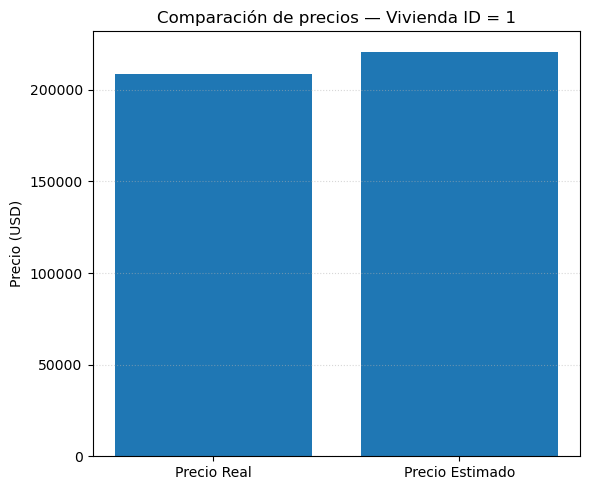

In [21]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: PRECIO REAL VS PRECIO ESTIMADO (INDIVIDUAL)
# ============================================================

plt.figure(figsize=(6,5))

valores = [precio_real, precio_estimado]
etiquetas = ["Precio Real", "Precio Estimado"]

plt.bar(etiquetas, valores)

plt.ylabel("Precio (USD)")
plt.title(f"Comparación de precios — Vivienda ID = {id_usuario}")

plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


**VARIABLES MAS IMPORTANTES EN MODELO NORMALIZADO**

In [22]:
import pandas as pd
import numpy as np

# ============================================================
# ANÁLISIS DE LA INFLUENCIA DE LAS VARIABLES (MODELO NORMALIZADO)
# ============================================================

# Quitamos el intercepto (primer coeficiente)
coeficientes_variables = coeficientes_norm[1:]

# Nombres de las variables del modelo
nombres_variables = X.columns.tolist()

# Influencia absoluta (magnitud del coeficiente)
influencia = np.abs(coeficientes_variables)

# Crear tabla resumen
tabla_influencia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes_variables,
    "Influencia (|coeficiente|)": influencia
})

# Ordenar de mayor a menor influencia
tabla_influencia = tabla_influencia.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO")
print("------------------------------------------------------")

display(tabla_influencia)


INFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO
------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,30539.199171,30539.199171
6,GrLivArea,24888.467207,24888.467207
2,YearBuilt,9205.378838,9205.378838
8,GarageCars,9028.515397,9028.515397
3,BsmtFinSF1,8489.615156,8489.615156
0,LotArea,5489.891633,5489.891633
4,TotalBsmtSF,4117.056018,4117.056018
5,1stFlrSF,3884.088361,3884.088361
9,GarageArea,1318.784814,1318.784814
7,FullBath,-1040.506472,1040.506472


**GRAFICA DE LAS VARIABLES IMPORTANTES EN MODELO NORMALIZADO**

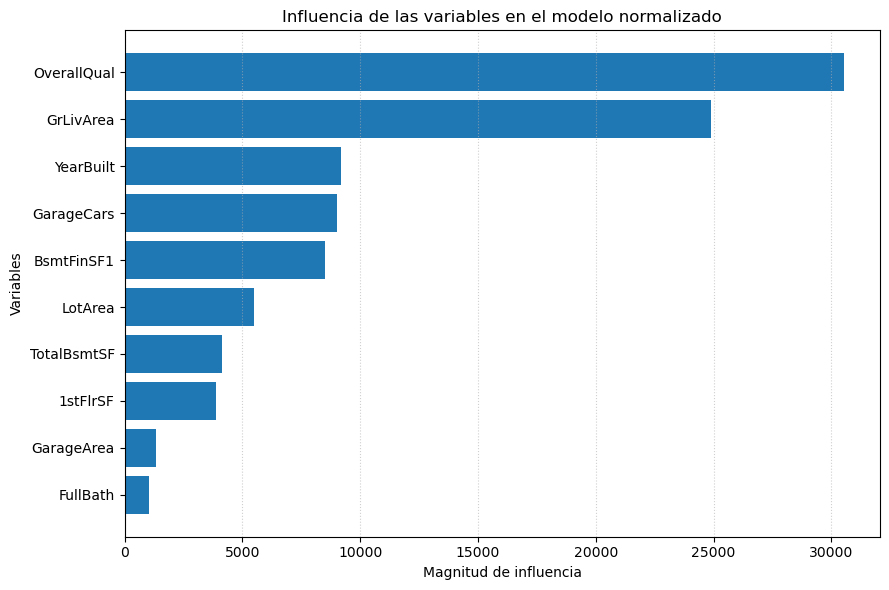

In [23]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA DE INFLUENCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9,6))

plt.barh(
    tabla_influencia["Variable"],
    tabla_influencia["Influencia (|coeficiente|)"]
)

plt.xlabel("Magnitud de influencia")
plt.ylabel("Variables")
plt.title("Influencia de las variables en el modelo normalizado")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


**TABLA TOP 10 PEORES PREDICCIONES**

In [24]:
import pandas as pd
import numpy as np

# ============================================================
# TOP 10 PEORES PREDICCIONES — MODELO NORMALIZADO (AUTÓNOMO)
# ============================================================

tabla_resultados_norm = pd.DataFrame({
    "ID": df["Id"],
    "Precio_Real": y.values,
    "Precio_Estimado": y_pred_norm
})

tabla_resultados_norm["Error"] = (
    tabla_resultados_norm["Precio_Real"] -
    tabla_resultados_norm["Precio_Estimado"]
)

tabla_resultados_norm["Error_Absoluto"] = np.abs(
    tabla_resultados_norm["Error"]
)

tabla_resultados_norm["Error_Porcentual (%)"] = (
    tabla_resultados_norm["Error_Absoluto"] /
    tabla_resultados_norm["Precio_Real"]
) * 100


top_peores_norm = tabla_resultados_norm.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES — MODELO NORMALIZADO")
print("------------------------------------------------")

display(top_peores_norm[[
    "ID",
    "Precio_Real",
    "Precio_Estimado",
    "Error",
    "Error_Absoluto",
    "Error_Porcentual (%)"
]])



TOP 10 PEORES PREDICCIONES — MODELO NORMALIZADO
------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1298,1299,160000,690546.501948,-530546.501948,530546.501948,331.591564
523,524,184750,531808.523175,-347058.523175,347058.523175,187.853057
691,692,755000,471797.486362,283202.513638,283202.513638,37.510267
1182,1183,745000,487765.553754,257234.446246,257234.446246,34.528114
803,804,582933,339297.879499,243635.120501,243635.120501,41.794704
898,899,611657,370680.092583,240976.907417,240976.907417,39.397392
1046,1047,556581,349358.531958,207222.468042,207222.468042,37.231323
1169,1170,625000,434890.542662,190109.457338,190109.457338,30.417513
440,441,555000,394441.056617,160558.943383,160558.943383,28.929539
769,770,538000,383147.332499,154852.667501,154852.667501,28.783024


**GRAFICAS TOP 10 PEORES PREDICCIONES NORMALIZADO**

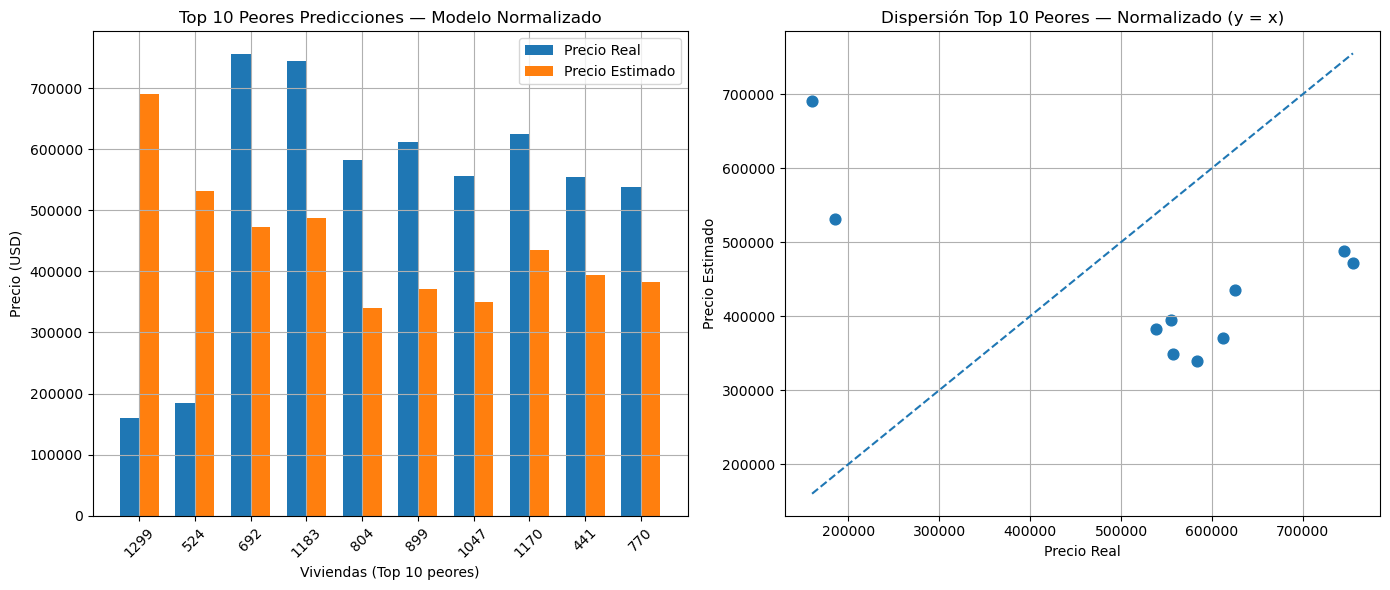

In [25]:
import matplotlib.pyplot as plt
import numpy as np

ids_norm = top_peores_norm["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS (IZQUIERDA)
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids_norm))
width = 0.35

plt.bar(x - width/2, top_peores_norm["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_peores_norm["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids_norm, rotation=45)
plt.xlabel("Viviendas (Top 10 peores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores Predicciones — Modelo Normalizado")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN (DERECHA)
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_peores_norm["Precio_Real"],
    top_peores_norm["Precio_Estimado"],
    s=60
)

min_val_norm = min(
    top_peores_norm["Precio_Real"].min(),
    top_peores_norm["Precio_Estimado"].min()
)

max_val_norm = max(
    top_peores_norm["Precio_Real"].max(),
    top_peores_norm["Precio_Estimado"].max()
)

plt.plot([min_val_norm, max_val_norm], [min_val_norm, max_val_norm], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Peores — Normalizado (y = x)")
plt.grid(True)


plt.tight_layout()
plt.show()


**TOP 10 MEJORES PREDICCIONES**

In [26]:
# ============================================================
# TOP 10 MEJORES PREDICCIONES — MODELO NORMALIZADO
# ============================================================

top_mejores_norm = tabla_resultados_norm.sort_values(
    by="Error_Absoluto",
    ascending=True
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES — MODELO NORMALIZADO")
print("------------------------------------------------")

display(top_mejores_norm)



TOP 10 MEJORES PREDICCIONES — MODELO NORMALIZADO
------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1401,1402,193000,193019.993435,-19.993435,19.993435,0.010359
1051,1052,200141,200113.790020,27.209980,27.209980,0.013595
433,434,181000,181046.548238,-46.548238,46.548238,0.025717
1410,1411,230000,230078.875549,-78.875549,78.875549,0.034294
650,651,205950,206034.822818,-84.822818,84.822818,0.041186
254,255,145000,145119.431719,-119.431719,119.431719,0.082367
1232,1233,101800,101923.457617,-123.457617,123.457617,0.121275
386,387,81000,80839.232090,160.767910,160.767910,0.198479
1117,1118,130000,129812.152533,187.847467,187.847467,0.144498
475,476,132500,132696.288408,-196.288408,196.288408,0.148142


**GRAFICA TOP 10 MEJORES PREDICCIONES**

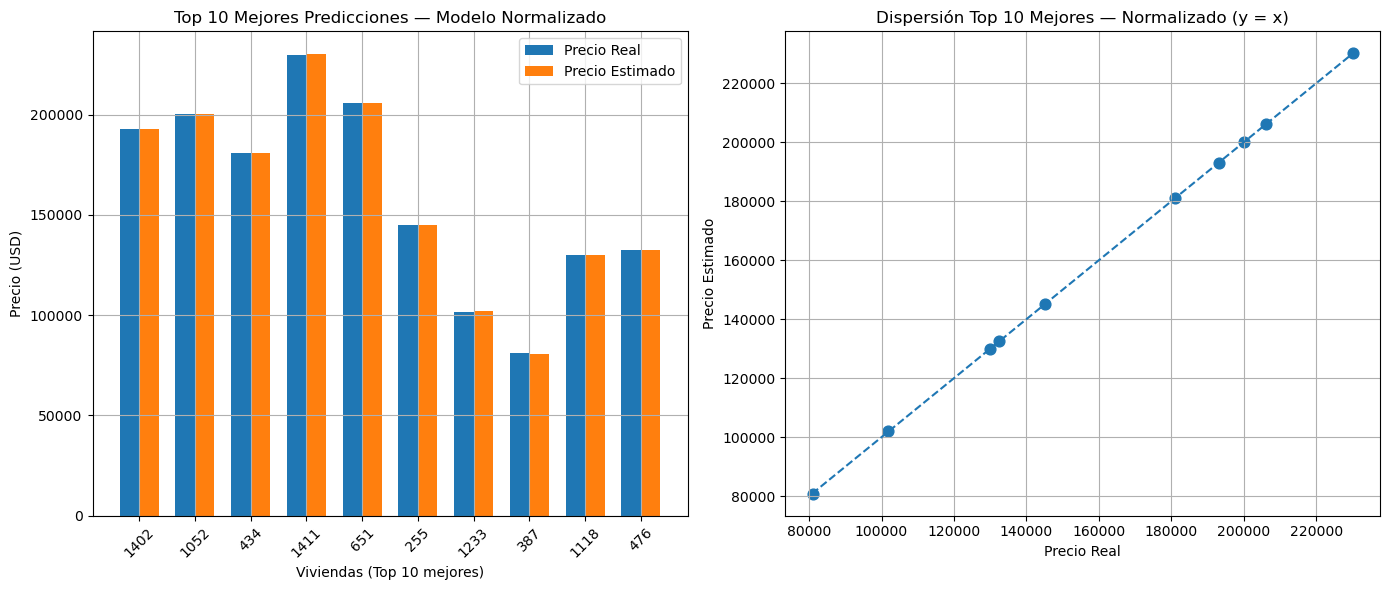

In [27]:

import matplotlib.pyplot as plt
import numpy as np

ids_mejores_norm = top_mejores_norm["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS (IZQUIERDA)
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids_mejores_norm))
width = 0.35

plt.bar(x - width/2, top_mejores_norm["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_mejores_norm["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids_mejores_norm, rotation=45)
plt.xlabel("Viviendas (Top 10 mejores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores Predicciones — Modelo Normalizado")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN (DERECHA)
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_mejores_norm["Precio_Real"],
    top_mejores_norm["Precio_Estimado"],
    s=60
)

min_val_mej = min(
    top_mejores_norm["Precio_Real"].min(),
    top_mejores_norm["Precio_Estimado"].min()
)

max_val_mej = max(
    top_mejores_norm["Precio_Real"].max(),
    top_mejores_norm["Precio_Estimado"].max()
)

plt.plot([min_val_mej, max_val_mej], [min_val_mej, max_val_mej], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Mejores — Normalizado (y = x)")
plt.grid(True)


plt.tight_layout()
plt.show()


**RMSE MODELO NORMALIZADO**

In [28]:
import numpy as np

# ============================================================
# RMSE — MODELO NORMALIZADO
# ============================================================

# Cálculo de residuos
residuos_norm = y.values - y_pred_norm

# Error cuadrático medio (MSE)
MSE_norm = np.mean(residuos_norm ** 2)

# Raíz del error cuadrático medio (RMSE)
RMSE_norm = np.sqrt(MSE_norm)

print("\nEVALUACIÓN GLOBAL — MODELO NORMALIZADO")
print("---------------------------------------")
print(f"MSE:  {MSE_norm:,.2f}")
print(f"RMSE: {RMSE_norm:,.2f} USD")



EVALUACIÓN GLOBAL — MODELO NORMALIZADO
---------------------------------------
MSE:  1,366,063,846.28
RMSE: 36,960.30 USD


**Grafica RMSE**

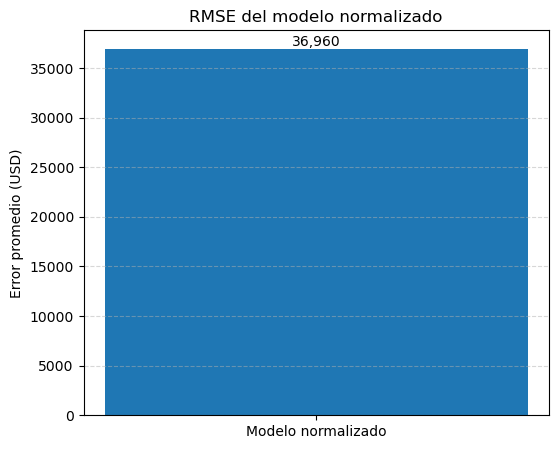

In [29]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICA DEL RMSE — MODELO NORMALIZADO
# ============================================

plt.figure(figsize=(6, 5))

plt.bar(["Modelo normalizado"], [RMSE_norm])

plt.ylabel("Error promedio (USD)")
plt.title("RMSE del modelo normalizado")

# Mostrar valor encima de la barra
plt.text(0, RMSE_norm, f"{RMSE_norm:,.0f}", 
         ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


**Distribucion de errores del modelo normalizado**

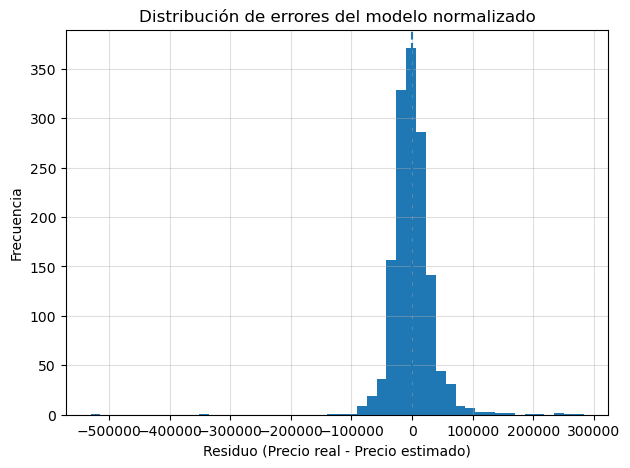

In [30]:
plt.figure(figsize=(7,5))

plt.hist(residuos_norm, bins=50)

plt.axvline(0, linestyle='--')

plt.xlabel("Residuo (Precio real - Precio estimado)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores del modelo normalizado")

plt.grid(True, alpha=0.4)

plt.show()


**Tabla de errores por Vivienda**

In [31]:
import pandas as pd
import numpy as np

# ============================================
# TABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)
# ============================================

# Precio real
precio_real = y.values

# Precio estimado
precio_estimado = y_pred_norm

# Error (residuo)
error = precio_real - precio_estimado

# Error absoluto
error_abs = np.abs(error)

# Error porcentual
error_pct = (error_abs / precio_real) * 100

# Construcción de la tabla
tabla_errores = pd.DataFrame({
    "Id": df["Id"],
    "Precio_Real": precio_real,
    "Precio_Estimado": precio_estimado,
    "Error": error,
    "Error_Absoluto": error_abs,
    "Error_Porcentual (%)": error_pct
})

print("\nTABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)")
print("---------------------------------------------------")

display(tabla_errores.head())



TABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)
---------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,220925.753821,-12425.753821,12425.753821,5.959594
1,2,181500,182437.793722,-937.793722,937.793722,0.516691
2,3,223500,222974.578680,525.421320,525.421320,0.235088
3,4,140000,200586.880949,-60586.880949,60586.880949,43.276344
4,5,250000,286926.357408,-36926.357408,36926.357408,14.770543


**GRAFICA DE ERRORES POR VIVIENDA NORMALIZADA**

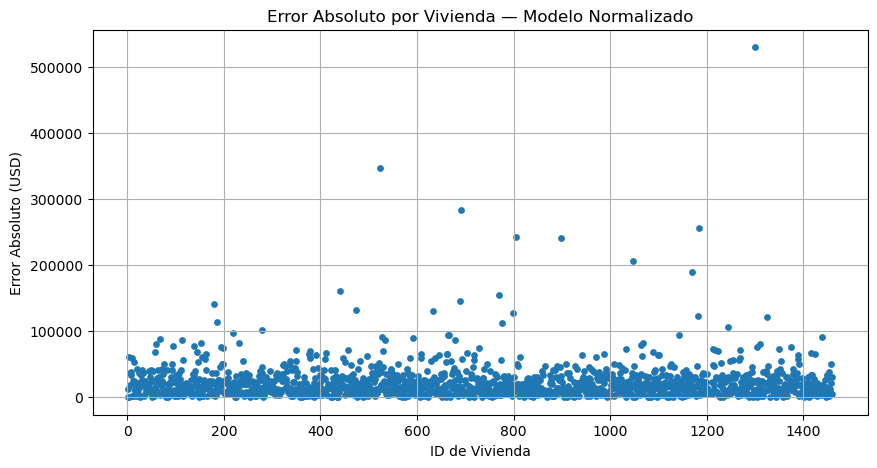

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    tabla_errores["Id"],
    tabla_errores["Error_Absoluto"],
    s=15
)

plt.xlabel("ID de Vivienda")
plt.ylabel("Error Absoluto (USD)")
plt.title("Error Absoluto por Vivienda — Modelo Normalizado")

plt.grid(True)
plt.show()


**MODELO 3 - DIAGRAMA DE CAJA**

**DIAGRAMA DE CAJA, NORMALIZACION Y ENTRENAMIENTO**

In [33]:
import numpy as np

# ============================================================
# MODELO 3 — LIMPIEZA DE DATOS CON BOXPLOT (IQR)
# ============================================================

# Trabajamos sobre el precio (SalePrice)
precios = df["SalePrice"].values

# Cuartiles
Q1 = np.percentile(precios, 25)
Q3 = np.percentile(precios, 75)

# Rango intercuartílico
IQR = Q3 - Q1

# Límites del boxplot
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nLÍMITES DEL BOXPLOT")
print("--------------------")
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Dataset limpio (sin valores atípicos)
df_m3 = df[
    (df["SalePrice"] >= limite_inferior) &
    (df["SalePrice"] <= limite_superior)
].copy()

print("\nRESUMEN LIMPIEZA")
print("----------------")
print("Datos originales:", len(df))
print("Datos después del boxplot:", len(df_m3))



LÍMITES DEL BOXPLOT
--------------------
Límite inferior: 3937.5
Límite superior: 340037.5

RESUMEN LIMPIEZA
----------------
Datos originales: 1460
Datos después del boxplot: 1399


In [34]:
import numpy as np

# ============================================================
# MODELO 3 — ENTRENAMIENTO CON DATASET LIMPIO + NORMALIZACIÓN
# ============================================================

# Variables explicativas
X_m3 = df_m3.drop("SalePrice", axis=1)

# Variable objetivo
y_m3 = df_m3["SalePrice"]

# Quitar Id
X_m3 = X_m3.drop("Id", axis=1)

print("\nCOLUMNAS DEL MODELO 3")
print("----------------------")
print(X_m3.columns.tolist())


# ===============================
# NORMALIZACIÓN (MODELO 3)
# ===============================

media_X_m3 = X_m3.mean()
std_X_m3 = X_m3.std()

X_m3_norm = (X_m3 - media_X_m3) / std_X_m3

print("\nPRIMERAS FILAS NORMALIZADAS (MODELO 3)")
print("-------------------------------------")
display(X_m3_norm.head())


# ===============================
# MATRIZ DEL MODELO
# ===============================

n_m3 = X_m3_norm.shape[0]

columna_unos_m3 = np.ones((n_m3, 1))

A_m3 = np.hstack((columna_unos_m3, X_m3_norm.values))

b_m3 = y_m3.values

print("\nDIMENSIÓN MATRIZ A (MODELO 3)")
print("------------------------------")
print(A_m3.shape)


# ===============================
# MÍNIMOS CUADRADOS
# ===============================

AT_m3 = A_m3.T

ATA_m3 = np.dot(AT_m3, A_m3)
ATb_m3 = np.dot(AT_m3, b_m3)

coeficientes_m3 = np.linalg.solve(ATA_m3, ATb_m3)

print("\nCOEFICIENTES MODELO 3")
print("----------------------")
print(coeficientes_m3)


# ===============================
# PREDICCIÓN GENERAL
# ===============================

y_pred_m3 = np.dot(A_m3, coeficientes_m3)

print("\nPRIMERAS 5 PREDICCIONES MODELO 3")
print("--------------------------------")
print(y_pred_m3[:5])

print("\nPRIMEROS 5 VALORES REALES MODELO 3")
print("----------------------------------")
print(y_m3.values[:5])



COLUMNAS DEL MODELO 3
----------------------
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

PRIMERAS FILAS NORMALIZADAS (MODELO 3)
-------------------------------------


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,-0.204843,0.792687,1.096962,0.673823,-0.413417,-0.773113,0.490240,0.855544,0.391403,0.436575
1,-0.066702,0.012821,0.197245,1.308741,0.584048,0.363129,-0.442020,0.855544,0.391403,0.005791
2,0.131500,0.792687,1.030316,0.160286,-0.256181,-0.594001,0.648392,0.855544,0.391403,0.730292
3,-0.072708,0.792687,-1.835447,-0.469963,-0.659098,-0.479257,0.504807,-1.005896,1.777664,0.896731
4,0.493069,1.572553,0.996993,0.554776,0.296601,0.035690,1.505738,0.855544,1.777664,1.846414



DIMENSIÓN MATRIZ A (MODELO 3)
------------------------------
(1399, 11)

COEFICIENTES MODELO 3
----------------------
[170237.12723374   5022.39571569  23459.84609448  10376.7172412
   4607.65227272   2539.57377678   1514.73937857  16844.94201972
    872.71108983   6801.49102495   2143.03528946]

PRIMERAS 5 PREDICCIONES MODELO 3
--------------------------------
[212673.70620133 176288.54440213 215269.30744031 186495.23071231
 265472.79888985]

PRIMEROS 5 VALORES REALES MODELO 3
----------------------------------
[208500 181500 223500 140000 250000]


**GRAFICA DE PREDICCION CON DIAGRAMA DE CAJA**

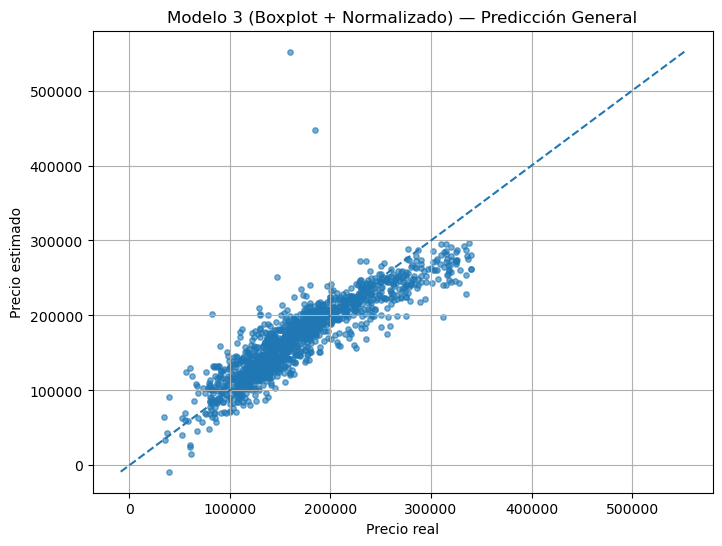

In [35]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: PRECIO REAL VS PRECIO ESTIMADO — MODELO 3
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(y_m3, y_pred_m3, alpha=0.6, s=15)

# Línea ideal y = x
min_val_m3 = min(y_m3.min(), y_pred_m3.min())
max_val_m3 = max(y_m3.max(), y_pred_m3.max())

plt.plot([min_val_m3, max_val_m3], [min_val_m3, max_val_m3], '--')

plt.xlabel("Precio real")
plt.ylabel("Precio estimado")
plt.title("Modelo 3 (Boxplot + Normalizado) — Predicción General")

plt.grid(True)
plt.show()


**PREDICCION POR ID CON DIAGRAMA DE CAJA**

In [36]:
import numpy as np

# ============================================================
# PREDICCIÓN INDIVIDUAL POR ID — MODELO 3
# ============================================================

# Ingreso del ID
id_usuario_m3 = int(input("Ingrese el ID de la vivienda que desea analizar (MODELO 3): "))

# Buscar vivienda en el dataset limpio
vivienda_m3 = df_m3[df_m3["Id"] == id_usuario_m3]

if vivienda_m3.empty:
    print(" ID no encontrado (puede haber sido eliminado por el boxplot)")

else:
    print("\nDatos originales de la vivienda seleccionada (MODELO 3):")
    display(vivienda_m3)

    # Preparar datos
    X_vivienda_m3 = vivienda_m3.drop(["SalePrice", "Id"], axis=1)

    # Normalización usando parámetros del MODELO 3
    X_vivienda_norm_m3 = (X_vivienda_m3 - media_X_m3) / std_X_m3

    # Convertir a vector NumPy
    fila_m3 = X_vivienda_norm_m3.values

    # Agregar intercepto
    fila_m3 = np.hstack(([1], fila_m3[0]))

    # Predicción
    precio_estimado_m3 = np.dot(fila_m3, coeficientes_m3)
    precio_real_m3 = vivienda_m3["SalePrice"].values[0]

    # Cálculo de errores
    error_abs_m3 = abs(precio_real_m3 - precio_estimado_m3)
    error_pct_m3 = (error_abs_m3 / precio_real_m3) * 100

    # Mostrar resultados
    print("\nRESULTADOS DE LA PREDICCIÓN — MODELO 3")
    print("--------------------------------------")
    print(f"Precio real:      ${precio_real_m3:,.2f}")
    print(f"Precio estimado:  ${precio_estimado_m3:,.2f}")
    print(f"Error absoluto:   ${error_abs_m3:,.2f}")
    print(f"Error porcentual: {error_pct_m3:.2f}%")


Ingrese el ID de la vivienda que desea analizar (MODELO 3):  1



Datos originales de la vivienda seleccionada (MODELO 3):


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN — MODELO 3
--------------------------------------
Precio real:      $208,500.00
Precio estimado:  $212,673.71
Error absoluto:   $4,173.71
Error porcentual: 2.00%


**GRAFICA DE PREDICCION POR ID CON DIAGRAMA DE CAJA**

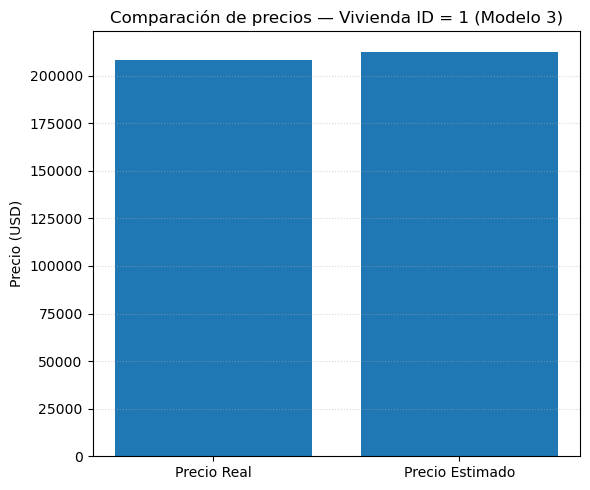

In [37]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: PRECIO REAL VS PRECIO ESTIMADO (INDIVIDUAL) — MODELO 3
# ============================================================

plt.figure(figsize=(6,5))

valores_m3 = [precio_real_m3, precio_estimado_m3]
etiquetas_m3 = ["Precio Real", "Precio Estimado"]

plt.bar(etiquetas_m3, valores_m3)

plt.ylabel("Precio (USD)")
plt.title(f"Comparación de precios — Vivienda ID = {id_usuario_m3} (Modelo 3)")

plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


**INFLUENCIA DE VARIABLES CON DIAGRAMA DE CAJAS**

In [38]:
import pandas as pd
import numpy as np

# ============================================================
# INFLUENCIA DE VARIABLES — MODELO 3
# ============================================================

# Quitamos el intercepto (primer coeficiente)
coeficientes_vars_m3 = coeficientes_m3[1:]

# Nombres de las variables
nombres_vars_m3 = X_m3.columns.tolist()

# Magnitud de influencia
influencia_m3 = np.abs(coeficientes_vars_m3)

# Construcción de tabla
tabla_influencia_m3 = pd.DataFrame({
    "Variable": nombres_vars_m3,
    "Coeficiente": coeficientes_vars_m3,
    "Influencia (|coeficiente|)": influencia_m3
})

# Ordenar de mayor a menor influencia
tabla_influencia_m3 = tabla_influencia_m3.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE VARIABLES — MODELO 3")
print("----------------------------------")

display(tabla_influencia_m3)



INFLUENCIA DE VARIABLES — MODELO 3
----------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,23459.846094,23459.846094
6,GrLivArea,16844.942020,16844.942020
2,YearBuilt,10376.717241,10376.717241
8,GarageCars,6801.491025,6801.491025
0,LotArea,5022.395716,5022.395716
3,BsmtFinSF1,4607.652273,4607.652273
4,TotalBsmtSF,2539.573777,2539.573777
9,GarageArea,2143.035289,2143.035289
5,1stFlrSF,1514.739379,1514.739379
7,FullBath,872.711090,872.711090


**GRAFICA DE VARIABLES IMPORTANTES CON DIAGRAMA DE CAJAS**

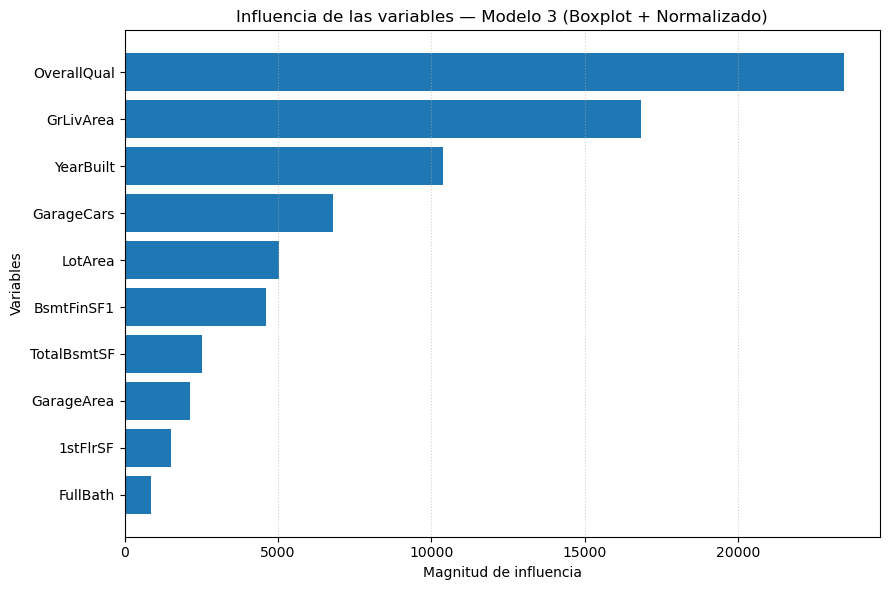

In [39]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA DE INFLUENCIA DE VARIABLES — MODELO 3
# ============================================================

plt.figure(figsize=(9,6))

plt.barh(
    tabla_influencia_m3["Variable"],
    tabla_influencia_m3["Influencia (|coeficiente|)"]
)

plt.xlabel("Magnitud de influencia")
plt.ylabel("Variables")
plt.title("Influencia de las variables — Modelo 3 (Boxplot + Normalizado)")

# Para que las más importantes queden arriba
plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


**TABLA TOP 10 PEORES PREDICCIONES**

In [40]:
import pandas as pd
import numpy as np

# ============================================================
# TOP 10 PEORES PREDICCIONES — MODELO 3 (AUTÓNOMO)
# ============================================================

tabla_resultados_m3 = pd.DataFrame({
    "ID": df_m3["Id"],
    "Precio_Real": y_m3.values,
    "Precio_Estimado": y_pred_m3
})

tabla_resultados_m3["Error"] = (
    tabla_resultados_m3["Precio_Real"] -
    tabla_resultados_m3["Precio_Estimado"]
)

tabla_resultados_m3["Error_Absoluto"] = np.abs(
    tabla_resultados_m3["Error"]
)

tabla_resultados_m3["Error_Porcentual (%)"] = (
    tabla_resultados_m3["Error_Absoluto"] /
    tabla_resultados_m3["Precio_Real"]
) * 100


top_peores_m3 = tabla_resultados_m3.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES — MODELO 3")
print("--------------------------------------")

display(top_peores_m3[[
    "ID",
    "Precio_Real",
    "Precio_Estimado",
    "Error",
    "Error_Absoluto",
    "Error_Porcentual (%)"
]])


TOP 10 PEORES PREDICCIONES — MODELO 3
--------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1298,1299,160000,551843.919120,-391843.919120,391843.919120,244.902449
523,524,184750,447206.174709,-262456.174709,262456.174709,142.060176
632,633,82500,202149.070495,-119649.070495,119649.070495,145.029176
218,219,311500,197498.186564,114001.813436,114001.813436,36.597693
1310,1311,335000,228338.026127,106661.973873,106661.973873,31.839395
1324,1325,147000,251227.619519,-104227.619519,104227.619519,70.903143
1065,1066,328000,242762.756869,85237.243131,85237.243131,25.986964
692,693,335000,254339.211523,80660.788477,80660.788477,24.077847
457,458,256000,175386.884143,80613.115857,80613.115857,31.489498
666,667,129000,209289.831457,-80289.831457,80289.831457,62.240179


**GRAFICA 10 PEORES PREDICCIONES**

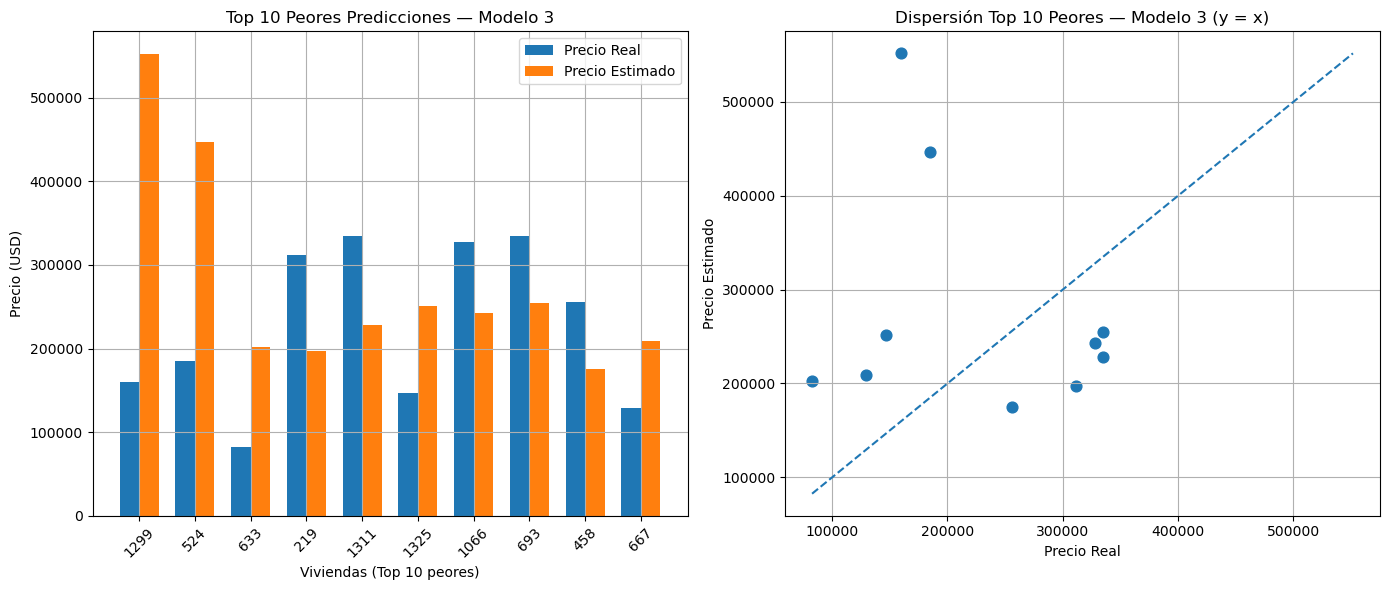

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRÁFICAS TOP 10 PEORES — MODELO 3
# ============================================================

ids_m3 = top_peores_m3["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids_m3))
width = 0.35

plt.bar(x - width/2, top_peores_m3["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_peores_m3["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids_m3, rotation=45)
plt.xlabel("Viviendas (Top 10 peores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores Predicciones — Modelo 3")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_peores_m3["Precio_Real"],
    top_peores_m3["Precio_Estimado"],
    s=60
)

min_val_m3 = min(
    top_peores_m3["Precio_Real"].min(),
    top_peores_m3["Precio_Estimado"].min()
)

max_val_m3 = max(
    top_peores_m3["Precio_Real"].max(),
    top_peores_m3["Precio_Estimado"].max()
)

plt.plot([min_val_m3, max_val_m3], [min_val_m3, max_val_m3], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Peores — Modelo 3 (y = x)")
plt.grid(True)


plt.tight_layout()
plt.show()


**TABLA TOP 10 MEJORES PREDICCIONES**

In [42]:
import pandas as pd
import numpy as np

# ============================================================
# TOP 10 MEJORES PREDICCIONES — MODELO 3 (AUTÓNOMO)
# ============================================================

tabla_resultados_m3_mejores = pd.DataFrame({
    "ID": df_m3["Id"],
    "Precio_Real": y_m3.values,
    "Precio_Estimado": y_pred_m3
})

tabla_resultados_m3_mejores["Error"] = (
    tabla_resultados_m3_mejores["Precio_Real"] -
    tabla_resultados_m3_mejores["Precio_Estimado"]
)

tabla_resultados_m3_mejores["Error_Absoluto"] = np.abs(
    tabla_resultados_m3_mejores["Error"]
)

tabla_resultados_m3_mejores["Error_Porcentual (%)"] = (
    tabla_resultados_m3_mejores["Error_Absoluto"] /
    tabla_resultados_m3_mejores["Precio_Real"]
) * 100


top_mejores_m3 = tabla_resultados_m3_mejores.sort_values(
    by="Error_Absoluto",
    ascending=True
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES — MODELO 3")
print("--------------------------------------")

display(top_mejores_m3[[
    "ID",
    "Precio_Real",
    "Precio_Estimado",
    "Error",
    "Error_Absoluto",
    "Error_Porcentual (%)"
]])



TOP 10 MEJORES PREDICCIONES — MODELO 3
--------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1407,1408,112000,111973.037876,26.962124,26.962124,0.024073
1001,1002,86000,85965.057038,34.942962,34.942962,0.040631
61,62,101000,101057.886056,-57.886056,57.886056,0.057313
872,873,116000,115937.237140,62.762860,62.762860,0.054106
880,881,157000,156927.218274,72.781726,72.781726,0.046358
360,361,156000,155926.999145,73.000855,73.000855,0.046795
1154,1155,201800,201879.773864,-79.773864,79.773864,0.039531
587,588,137000,136918.029553,81.970447,81.970447,0.059832
1041,1042,173000,173086.485005,-86.485005,86.485005,0.049991
334,335,192000,191909.080188,90.919812,90.919812,0.047354


**GRAFICA TOP 10 MEJORES PREDICCIONES**

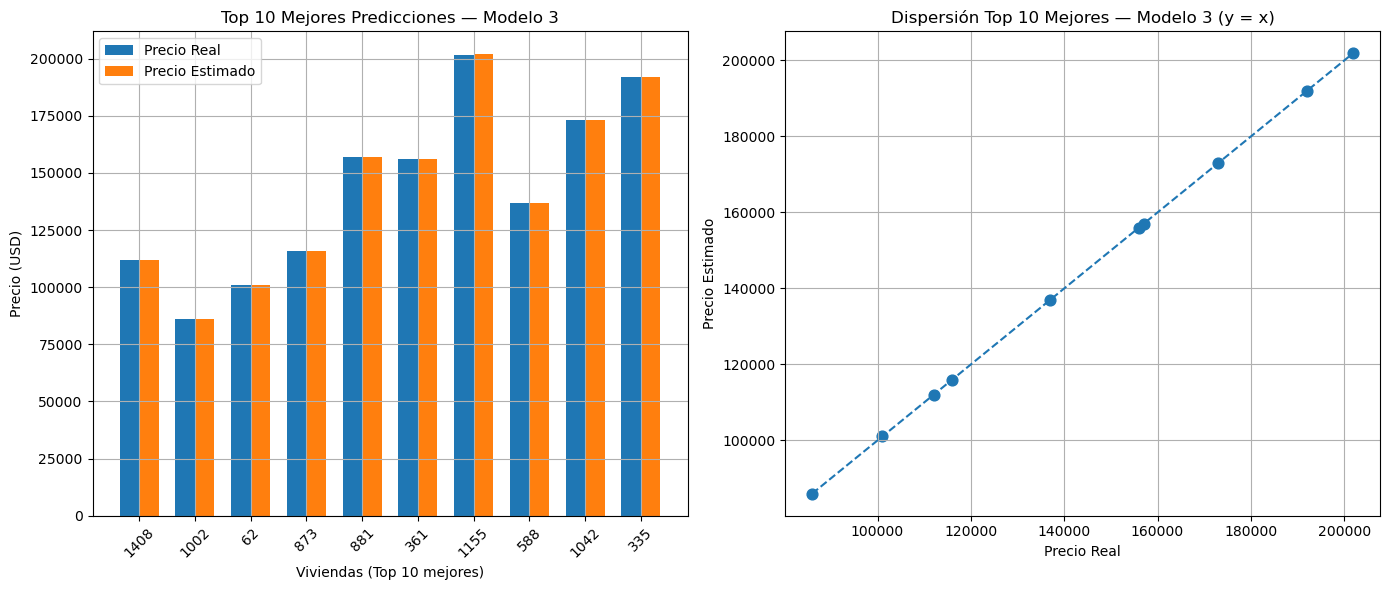

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRÁFICAS TOP 10 MEJORES — MODELO 3
# ============================================================

ids_mej_m3 = top_mejores_m3["ID"].astype(str)

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1: BARRAS
# ============================

plt.subplot(1, 2, 1)

x = np.arange(len(ids_mej_m3))
width = 0.35

plt.bar(x - width/2, top_mejores_m3["Precio_Real"], width, label="Precio Real")
plt.bar(x + width/2, top_mejores_m3["Precio_Estimado"], width, label="Precio Estimado")

plt.xticks(x, ids_mej_m3, rotation=45)
plt.xlabel("Viviendas (Top 10 mejores)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores Predicciones — Modelo 3")
plt.legend()
plt.grid(True)


# ============================
# GRÁFICO 2: DISPERSIÓN
# ============================

plt.subplot(1, 2, 2)

plt.scatter(
    top_mejores_m3["Precio_Real"],
    top_mejores_m3["Precio_Estimado"],
    s=60
)

min_val_mej_m3 = min(
    top_mejores_m3["Precio_Real"].min(),
    top_mejores_m3["Precio_Estimado"].min()
)

max_val_mej_m3 = max(
    top_mejores_m3["Precio_Real"].max(),
    top_mejores_m3["Precio_Estimado"].max()
)

plt.plot([min_val_mej_m3, max_val_mej_m3], [min_val_mej_m3, max_val_mej_m3], '--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Dispersión Top 10 Mejores — Modelo 3 (y = x)")
plt.grid(True)


plt.tight_layout()
plt.show()


**RMSE CON DIAGRAMA DE CAJA**

In [44]:
import numpy as np

# ============================================================
# RMSE — MODELO 3 (BOXPLOT + NORMALIZADO)
# ============================================================

# Cálculo de residuos
residuos_m3 = y_m3.values - y_pred_m3

# Error cuadrático medio (MSE)
MSE_m3 = np.mean(residuos_m3 ** 2)

# Raíz del error cuadrático medio (RMSE)
RMSE_m3 = np.sqrt(MSE_m3)

print("\nEVALUACIÓN GLOBAL — MODELO 3")
print("--------------------------------")
print(f"MSE:  {MSE_m3:,.2f}")
print(f"RMSE: {RMSE_m3:,.2f} USD")



EVALUACIÓN GLOBAL — MODELO 3
--------------------------------
MSE:  768,913,742.23
RMSE: 27,729.29 USD


**GRAFICA RMSE CON DIAGRAMA DE CAJA**

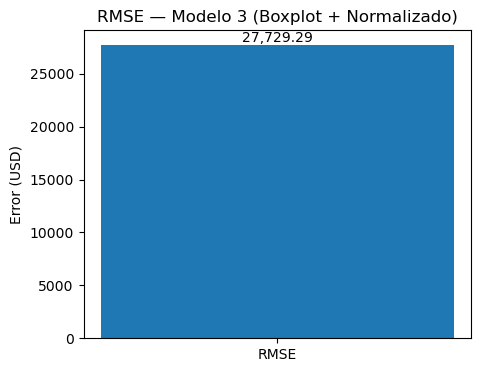

In [45]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA RMSE — MODELO 3
# ============================================================

plt.figure(figsize=(5,4))

bars_m3 = plt.bar(["RMSE"], [RMSE_m3])

plt.ylabel("Error (USD)")
plt.title("RMSE — Modelo 3 (Boxplot + Normalizado)")

# Mostrar valor encima de la barra
for bar in bars_m3:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.2f}",
        ha='center',
        va='bottom'
    )

# Sin cuadrícula para que no corte el texto
plt.grid(False)

plt.show()

**DISTRIBUCION DE ERRORES CON DIAGRAMA DE CAJA**

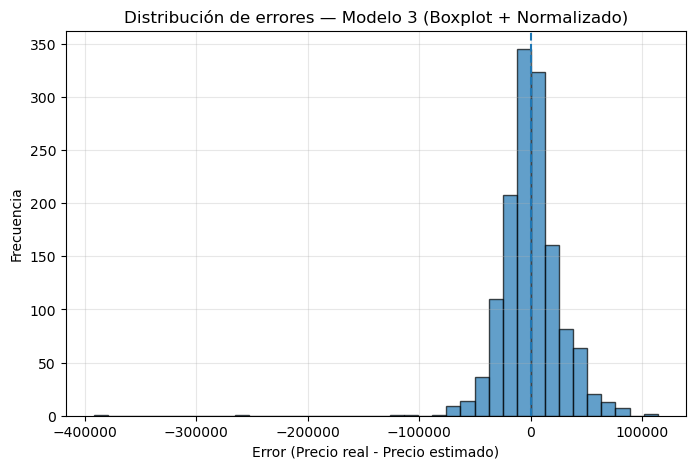

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DISTRIBUCIÓN DE ERRORES — MODELO 3
# ============================================================

# Residuos del modelo 3
errores_m3 = y_m3.values - y_pred_m3

plt.figure(figsize=(8,5))

plt.hist(errores_m3, bins=40, edgecolor='black', alpha=0.7)

# Línea vertical en cero (error ideal)
plt.axvline(0, linestyle='--')

plt.title("Distribución de errores — Modelo 3 (Boxplot + Normalizado)")
plt.xlabel("Error (Precio real - Precio estimado)")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)
plt.show()

**TABLA DE ERRORES POR VIVIENDA CON DIAGRAMA DE CAJAS**

In [47]:
import pandas as pd
import numpy as np

# ============================================================
# TABLA DE ERRORES POR VIVIENDA — MODELO 3 (AUTÓNOMA)
# ============================================================

tabla_errores_m3 = pd.DataFrame({
    "Id": df_m3["Id"],
    "Precio_Real": y_m3.values,
    "Precio_Estimado": y_pred_m3
})

tabla_errores_m3["Error"] = (
    tabla_errores_m3["Precio_Real"] -
    tabla_errores_m3["Precio_Estimado"]
)

tabla_errores_m3["Error_Absoluto"] = np.abs(
    tabla_errores_m3["Error"]
)

tabla_errores_m3["Error_Porcentual (%)"] = (
    tabla_errores_m3["Error_Absoluto"] /
    tabla_errores_m3["Precio_Real"]
) * 100


print("\nTABLA DE ERRORES POR VIVIENDA — MODELO 3")
print("----------------------------------------")

display(tabla_errores_m3.head())



TABLA DE ERRORES POR VIVIENDA — MODELO 3
----------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,212673.706201,-4173.706201,4173.706201,2.001778
1,2,181500,176288.544402,5211.455598,5211.455598,2.871325
2,3,223500,215269.307440,8230.692560,8230.692560,3.682636
3,4,140000,186495.230712,-46495.230712,46495.230712,33.210879
4,5,250000,265472.798890,-15472.798890,15472.798890,6.189120


**GRAFICA DE TABLA DE ERRORES POR VIVIENDA**

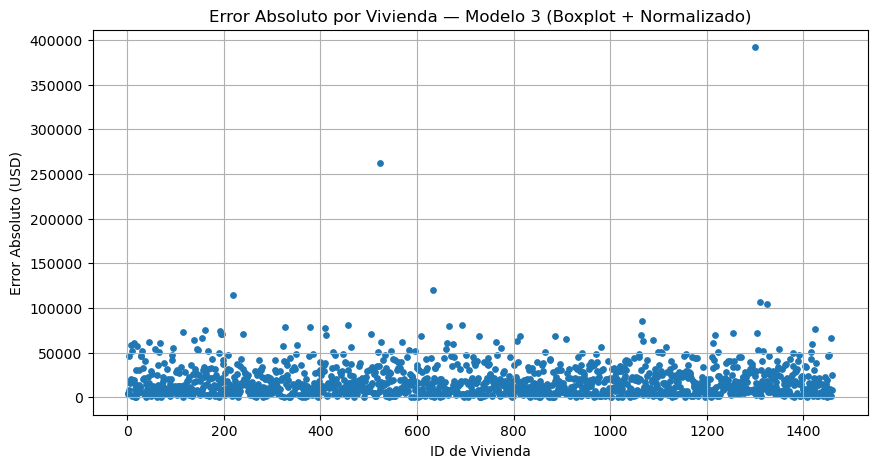

In [48]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: ERROR ABSOLUTO POR VIVIENDA — MODELO 3
# ============================================================

plt.figure(figsize=(10,5))

plt.scatter(
    tabla_errores_m3["Id"],
    tabla_errores_m3["Error_Absoluto"],
    s=15
)

plt.xlabel("ID de Vivienda")
plt.ylabel("Error Absoluto (USD)")
plt.title("Error Absoluto por Vivienda — Modelo 3 (Boxplot + Normalizado)")

plt.grid(True)
plt.show()


**COMPARACION FINAL DEFINITIVAD**

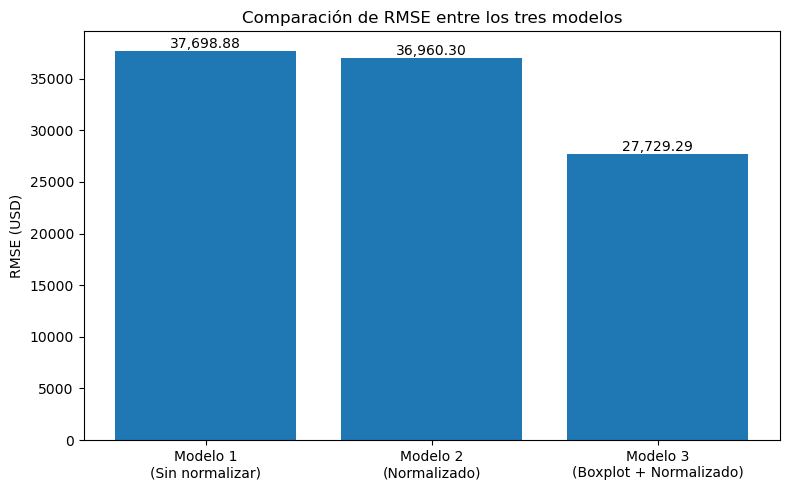

In [49]:
import matplotlib.pyplot as plt

# ============================================================
# COMPARACIÓN RMSE — MODELO 1 vs MODELO 2 vs MODELO 3
# ============================================================

modelos = ["Modelo 1\n(Sin normalizar)", 
           "Modelo 2\n(Normalizado)", 
           "Modelo 3\n(Boxplot + Normalizado)"]

valores_rmse = [RMSE, RMSE_norm, RMSE_m3]

plt.figure(figsize=(8,5))

bars = plt.bar(modelos, valores_rmse)

plt.ylabel("RMSE (USD)")
plt.title("Comparación de RMSE entre los tres modelos")

# Mostrar valores arriba de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.2f}",
        ha='center',
        va='bottom'
    )

# Sin cuadrícula para que no se vea cargado
plt.grid(False)

plt.tight_layout()
plt.show()


**TRAIN/TEST**

In [50]:
import numpy as np

# ============================================================
# MODELO 3 — TRAIN / TEST (70% / 30%)
# ============================================================

# Semilla para que siempre salga igual (mañana en otra PC también)
np.random.seed(42)

# Mezclar índices
indices = np.random.permutation(len(df_m3))

# Tamaño train (70%)
tam_train = int(0.7 * len(df_m3))

# Índices train y test
train_idx = indices[:tam_train]
test_idx = indices[tam_train:]

# Crear dataframes
df_train_m3 = df_m3.iloc[train_idx].copy()
df_test_m3 = df_m3.iloc[test_idx].copy()

print("\nDIVISIÓN DE DATOS — MODELO 3")
print("----------------------------")
print("Total datos:", len(df_m3))
print("Train (70%):", len(df_train_m3))
print("Test (30%): ", len(df_test_m3))



DIVISIÓN DE DATOS — MODELO 3
----------------------------
Total datos: 1399
Train (70%): 979
Test (30%):  420


In [51]:
import numpy as np

# ============================================================
# SEPARACIÓN DE VARIABLES — TRAIN Y TEST (MODELO 3)
# ============================================================

# ---------- TRAIN ----------
X_train_m3 = df_train_m3.drop("SalePrice", axis=1)
y_train_m3 = df_train_m3["SalePrice"]

X_train_m3 = X_train_m3.drop("Id", axis=1)

# ---------- TEST ----------
X_test_m3 = df_test_m3.drop("SalePrice", axis=1)
y_test_m3 = df_test_m3["SalePrice"]

X_test_m3 = X_test_m3.drop("Id", axis=1)


print("\nColumnas del modelo (Train/Test)")
print("--------------------------------")
print(X_train_m3.columns.tolist())


# ============================================================
# NORMALIZACIÓN — USANDO SOLO TRAIN
# ============================================================

media_train_m3 = X_train_m3.mean()
std_train_m3 = X_train_m3.std()

# Normalizar TRAIN
X_train_norm_m3 = (X_train_m3 - media_train_m3) / std_train_m3

# Normalizar TEST con parámetros del TRAIN
X_test_norm_m3 = (X_test_m3 - media_train_m3) / std_train_m3


print("\nPrimeras filas TRAIN normalizado:")
display(X_train_norm_m3.head())

print("\nPrimeras filas TEST normalizado:")
display(X_test_norm_m3.head())



Columnas del modelo (Train/Test)
--------------------------------
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

Primeras filas TRAIN normalizado:


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
703,-0.310539,-0.751996,-2.329215,-1.014078,-1.678671,-0.287422,0.763898,0.870643,0.394842,1.055294
656,0.003952,-0.751996,-0.367279,0.967999,0.091883,-0.228026,-0.897475,-1.006801,-0.990643,-0.720815
119,-0.200593,0.023772,1.162366,-1.014078,-0.738463,-1.147257,-0.015349,0.870643,0.394842,-0.335991
502,-0.106788,-0.751996,-0.167760,0.702411,0.503224,0.227347,-0.545062,-1.006801,0.394842,0.014297
243,0.103842,0.023772,0.331037,-1.014078,-0.999064,-1.435754,-0.538496,-1.006801,-0.990643,-0.839222



Primeras filas TEST normalizado:


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
953,0.145254,-0.751996,-0.034748,0.367966,-0.595388,0.097240,1.105366,0.870643,0.394842,0.354718
1293,0.021548,0.799540,0.198024,-0.537002,-0.472752,-0.853103,0.439942,0.870643,0.394842,0.344850
896,-0.160372,-1.527764,-1.132102,-0.313219,-0.168718,-0.516523,-1.120742,-1.006801,-0.990643,-0.646810
1429,0.339876,0.023772,0.364290,0.653228,1.080633,0.866566,-0.050371,0.870643,0.394842,0.043899
165,0.017050,-0.751996,-0.999089,-0.150915,-0.953076,-0.920985,-0.236428,0.870643,-2.376128,-2.260109


In [52]:
import numpy as np

# ============================================================
# ENTRENAMIENTO — MODELO 3 (USANDO SOLO TRAIN)
# ============================================================

# Número de muestras train
n_train_m3 = X_train_norm_m3.shape[0]

# Columna de unos (intercepto)
columna_unos_train = np.ones((n_train_m3, 1))

# Matriz A de entrenamiento
A_train_m3 = np.hstack((columna_unos_train, X_train_norm_m3.values))

# Vector b (precios reales train)
b_train_m3 = y_train_m3.values

print("\nDimensión matriz A_train:")
print(A_train_m3.shape)


# ============================================================
# MÍNIMOS CUADRADOS — ECUACIÓN NORMAL
# ============================================================

AT_train = A_train_m3.T

ATA_train = np.dot(AT_train, A_train_m3)
ATb_train = np.dot(AT_train, b_train_m3)

coeficientes_train_m3 = np.linalg.solve(ATA_train, ATb_train)

print("\nCoeficientes del MODELO 3 (TRAIN)")
print("---------------------------------")
print(coeficientes_train_m3)



Dimensión matriz A_train:
(979, 11)

Coeficientes del MODELO 3 (TRAIN)
---------------------------------
[169330.22165475   5058.13124961  23795.99206051   9839.69056696
   5904.19105439   6121.08325732   -598.36120196  18313.41451374
   -721.80451178    968.04489408   6611.31693392]


In [53]:
import numpy as np

# ============================================================
# PREDICCIÓN — MODELO 3 (SOBRE TEST)
# ============================================================

# Número de muestras test
n_test_m3 = X_test_norm_m3.shape[0]

# Columna de unos (intercepto)
columna_unos_test = np.ones((n_test_m3, 1))

# Matriz A del test
A_test_m3 = np.hstack((columna_unos_test, X_test_norm_m3.values))

# Predicción usando coeficientes entrenados
y_pred_test_m3 = np.dot(A_test_m3, coeficientes_train_m3)

print("\nPrimeras 5 predicciones TEST:")
print(y_pred_test_m3[:5])

print("\nPrimeros 5 valores reales TEST:")
print(y_test_m3.values[:5])



Primeras 5 predicciones TEST:
[172640.44871896 194950.25408967  93418.71690057 184273.99774845
 113316.7146671 ]

Primeros 5 valores reales TEST:
[172000 162900 106500 182900 127500]


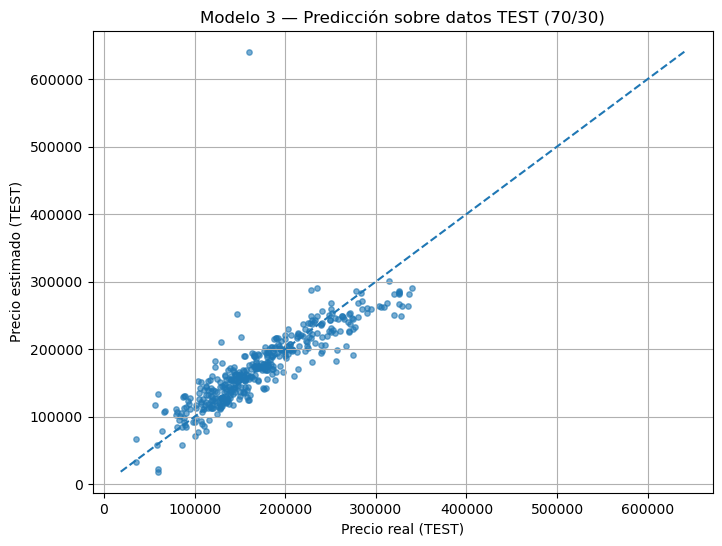

In [54]:
    import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: PRECIO REAL VS PRECIO ESTIMADO — TEST (MODELO 3)
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test_m3, y_pred_test_m3, alpha=0.6, s=15)

# Línea ideal y = x
min_val_test = min(y_test_m3.min(), y_pred_test_m3.min())
max_val_test = max(y_test_m3.max(), y_pred_test_m3.max())

plt.plot([min_val_test, max_val_test], [min_val_test, max_val_test], '--')

plt.xlabel("Precio real (TEST)")
plt.ylabel("Precio estimado (TEST)")
plt.title("Modelo 3 — Predicción sobre datos TEST (70/30)")

plt.grid(True)
plt.show()


In [55]:
import numpy as np

# ============================================================
# RMSE — MODELO 3 (SOBRE TEST)
# ============================================================

# Cálculo de residuos (error)
residuos_test_m3 = y_test_m3.values - y_pred_test_m3

# Error cuadrático medio
MSE_test_m3 = np.mean(residuos_test_m3 ** 2)

# Raíz del error cuadrático medio
RMSE_test_m3 = np.sqrt(MSE_test_m3)

print("\nEVALUACIÓN MODELO 3 — TEST (70/30)")
print("----------------------------------")
print(f"MSE TEST:  {MSE_test_m3:,.2f}")
print(f"RMSE TEST: {RMSE_test_m3:,.2f} USD")



EVALUACIÓN MODELO 3 — TEST (70/30)
----------------------------------
MSE TEST:  1,154,097,580.01
RMSE TEST: 33,972.01 USD


In [56]:
import numpy as np

# ============================================================
# RMSE — MODELO 3 (SOBRE TEST)
# ============================================================

# Cálculo de residuos (error)
residuos_test_m3 = y_test_m3.values - y_pred_test_m3

# Error cuadrático medio
MSE_test_m3 = np.mean(residuos_test_m3 ** 2)

# Raíz del error cuadrático medio
RMSE_test_m3 = np.sqrt(MSE_test_m3)

print("\nEVALUACIÓN MODELO 3 — TEST (70/30)")
print("----------------------------------")
print(f"MSE TEST:  {MSE_test_m3:,.2f}")
print(f"RMSE TEST: {RMSE_test_m3:,.2f} USD")



EVALUACIÓN MODELO 3 — TEST (70/30)
----------------------------------
MSE TEST:  1,154,097,580.01
RMSE TEST: 33,972.01 USD


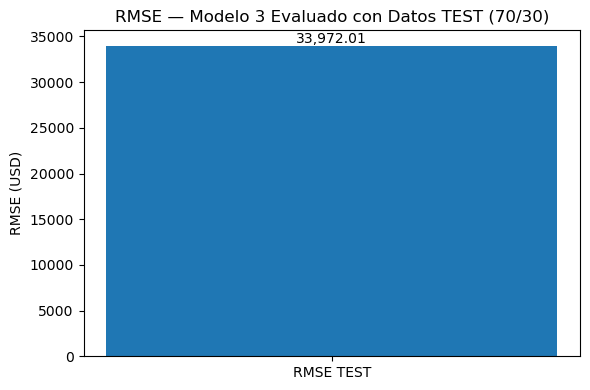

In [57]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA RMSE — MODELO 3 (TEST)
# ============================================================

plt.figure(figsize=(6,4))

plt.bar(["RMSE TEST"], [RMSE_test_m3])

# Mostrar valor arriba de la barra
plt.text(
    0,
    RMSE_test_m3,
    f"{RMSE_test_m3:,.2f}",
    ha='center',
    va='bottom'
)

plt.ylabel("RMSE (USD)")
plt.title("RMSE — Modelo 3 Evaluado con Datos TEST (70/30)")

# Sin rejilla para que no tape el valor
plt.grid(False)

plt.tight_layout()
plt.show()


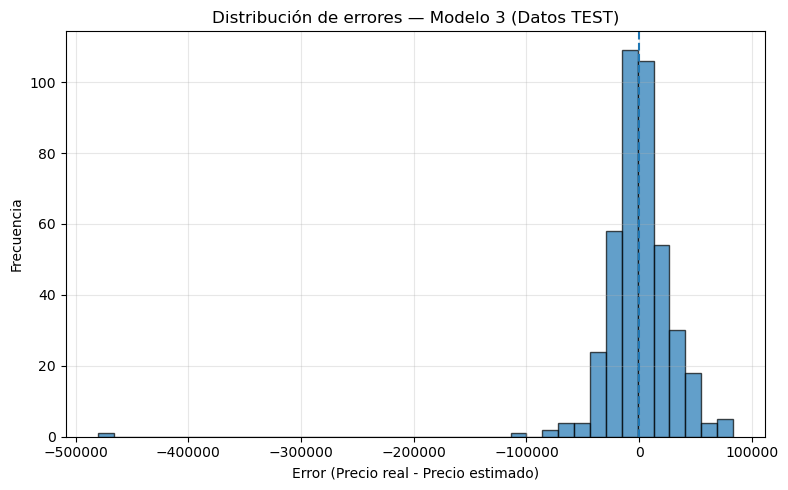

In [58]:
import matplotlib.pyplot as plt

# ============================================================
# DISTRIBUCIÓN DE ERRORES — MODELO 3 (TEST)
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(residuos_test_m3, bins=40, edgecolor='black', alpha=0.7)

# Línea vertical en cero (error ideal)
plt.axvline(0, linestyle='--')

plt.xlabel("Error (Precio real - Precio estimado)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores — Modelo 3 (Datos TEST)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [59]:
import pandas as pd
import numpy as np

# ============================================================
# TABLA DE ERRORES POR VIVIENDA — MODELO 3 (TEST)
# ============================================================

# Precio real TEST
precio_real_test_m3 = y_test_m3.values

# Precio estimado TEST
precio_estimado_test_m3 = y_pred_test_m3

# Error (residuo)
error_test_m3 = precio_real_test_m3 - precio_estimado_test_m3

# Error absoluto
error_abs_test_m3 = np.abs(error_test_m3)

# Error porcentual
error_pct_test_m3 = (error_abs_test_m3 / precio_real_test_m3) * 100


# Construcción de tabla
tabla_errores_test_m3 = pd.DataFrame({
    "Id": df_test_m3["Id"].values,
    "Precio_Real": precio_real_test_m3,
    "Precio_Estimado": precio_estimado_test_m3,
    "Error": error_test_m3,
    "Error_Absoluto": error_abs_test_m3,
    "Error_Porcentual (%)": error_pct_test_m3
})

print("\nTABLA DE ERRORES POR VIVIENDA — MODELO 3 (TEST)")
print("------------------------------------------------")

display(tabla_errores_test_m3.head())



TABLA DE ERRORES POR VIVIENDA — MODELO 3 (TEST)
------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,954,172000,172640.448719,-640.448719,640.448719,0.372354
1,1294,162900,194950.254090,-32050.254090,32050.254090,19.674803
2,897,106500,93418.716901,13081.283099,13081.283099,12.282895
3,1430,182900,184273.997748,-1373.997748,1373.997748,0.751229
4,166,127500,113316.714667,14183.285333,14183.285333,11.124145


In [60]:
# ============================================================
# TOP 10 PEORES PREDICCIONES — MODELO 3 (TEST)
# ============================================================

top_peores_test_m3 = tabla_errores_test_m3.sort_values(
    by="Error_Absoluto",
    ascending=False
).head(10)

print("\nTOP 10 PEORES PREDICCIONES — MODELO 3 (TEST)")
print("--------------------------------------------")

display(top_peores_test_m3)



TOP 10 PEORES PREDICCIONES — MODELO 3 (TEST)
--------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
296,1299,160000,640401.621546,-480401.621546,480401.621546,300.251013
380,1325,147000,252300.285341,-105300.285341,105300.285341,71.632847
382,1424,274970,191818.637449,83151.362551,83151.362551,30.240158
264,667,129000,211154.608110,-82154.608110,82154.608110,63.685743
342,1066,328000,249363.447205,78636.552795,78636.552795,23.974559
320,411,60000,133789.498466,-73789.498466,73789.498466,122.982497
157,458,256000,182853.891776,73146.108224,73146.108224,28.572699
71,693,335000,263891.003639,71108.996361,71108.996361,21.226566
118,160,320000,249996.594385,70003.405615,70003.405615,21.876064
149,1069,151400,217574.264978,-66174.264978,66174.264978,43.708233


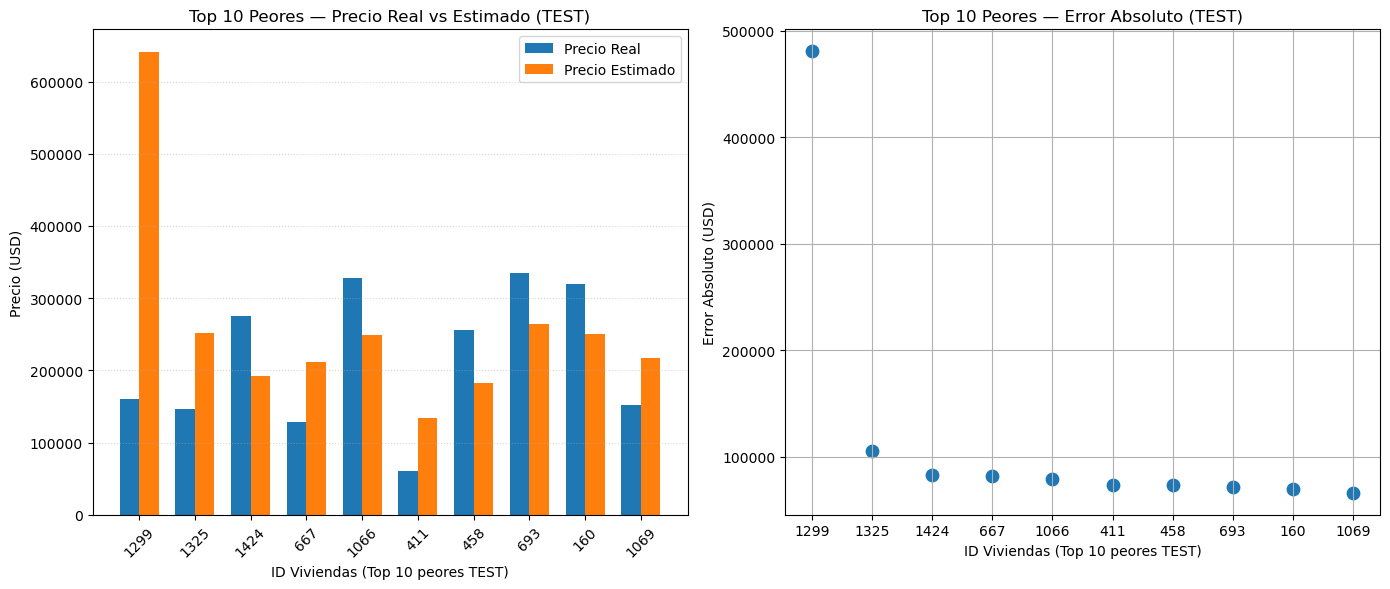

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TOP 10 PEORES — MODELO 3 (TEST) — GRÁFICAS JUNTAS
# ============================================================

ids = top_peores_test_m3["Id"].astype(str)

precio_real = top_peores_test_m3["Precio_Real"]
precio_estimado = top_peores_test_m3["Precio_Estimado"]
error_abs = top_peores_test_m3["Error_Absoluto"]

x = np.arange(len(ids))
ancho = 0.35

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1 — BARRAS (PRECIOS)
# ============================

plt.subplot(1, 2, 1)

plt.bar(x - ancho/2, precio_real, ancho, label="Precio Real")
plt.bar(x + ancho/2, precio_estimado, ancho, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("ID Viviendas (Top 10 peores TEST)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Peores — Precio Real vs Estimado (TEST)")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)


# ============================
# GRÁFICO 2 — ERROR ABSOLUTO
# ============================

plt.subplot(1, 2, 2)

plt.scatter(ids, error_abs, s=80)

plt.xlabel("ID Viviendas (Top 10 peores TEST)")
plt.ylabel("Error Absoluto (USD)")
plt.title("Top 10 Peores — Error Absoluto (TEST)")

plt.grid(True)


plt.tight_layout()
plt.show()


In [62]:
# ============================================================
# TOP 10 MEJORES PREDICCIONES — MODELO 3 (TEST)
# ============================================================

top_mejores_test_m3 = tabla_errores_test_m3.sort_values(
    by="Error_Absoluto",
    ascending=True
).head(10)

print("\nTOP 10 MEJORES PREDICCIONES — MODELO 3 (TEST)")
print("---------------------------------------------")

display(top_mejores_test_m3)



TOP 10 MEJORES PREDICCIONES — MODELO 3 (TEST)
---------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
268,681,143000,143054.969871,-54.969871,54.969871,0.038440
363,1440,197000,196883.697397,116.302603,116.302603,0.059037
361,819,155000,154832.433707,167.566293,167.566293,0.108107
353,742,142000,141745.344576,254.655424,254.655424,0.179335
62,835,139950,139607.545872,342.454128,342.454128,0.244697
187,1197,219210,218848.248349,361.751651,361.751651,0.165025
378,1208,200000,200560.731712,-560.731712,560.731712,0.280366
265,1425,144000,143419.895226,580.104774,580.104774,0.402851
0,954,172000,172640.448719,-640.448719,640.448719,0.372354
276,1109,181000,180300.719672,699.280328,699.280328,0.386343


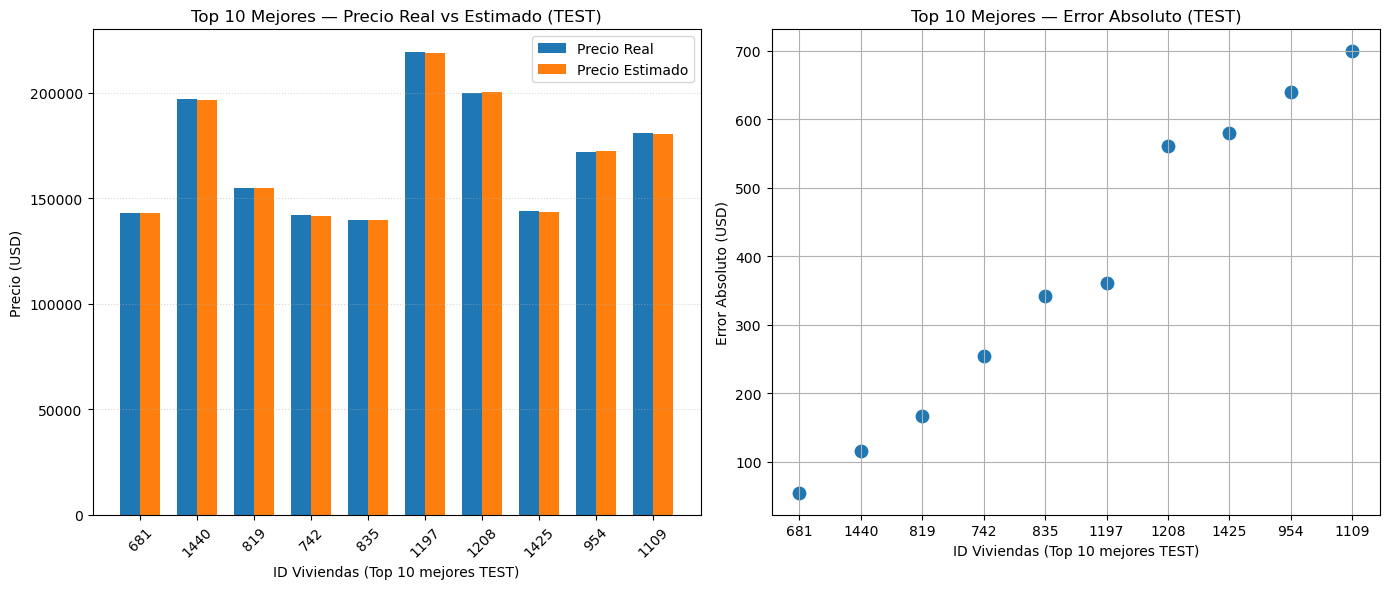

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# TOP 10 MEJORES — MODELO 3 (TEST) — GRÁFICAS JUNTAS
# ============================================================

ids = top_mejores_test_m3["Id"].astype(str)

precio_real = top_mejores_test_m3["Precio_Real"]
precio_estimado = top_mejores_test_m3["Precio_Estimado"]
error_abs = top_mejores_test_m3["Error_Absoluto"]

x = np.arange(len(ids))
ancho = 0.35

plt.figure(figsize=(14,6))

# ============================
# GRÁFICO 1 — BARRAS (PRECIOS)
# ============================

plt.subplot(1, 2, 1)

plt.bar(x - ancho/2, precio_real, ancho, label="Precio Real")
plt.bar(x + ancho/2, precio_estimado, ancho, label="Precio Estimado")

plt.xticks(x, ids, rotation=45)
plt.xlabel("ID Viviendas (Top 10 mejores TEST)")
plt.ylabel("Precio (USD)")
plt.title("Top 10 Mejores — Precio Real vs Estimado (TEST)")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)


# ============================
# GRÁFICO 2 — ERROR ABSOLUTO
# ============================

plt.subplot(1, 2, 2)

plt.scatter(ids, error_abs, s=80)

plt.xlabel("ID Viviendas (Top 10 mejores TEST)")
plt.ylabel("Error Absoluto (USD)")
plt.title("Top 10 Mejores — Error Absoluto (TEST)")

plt.grid(True)


plt.tight_layout()
plt.show()


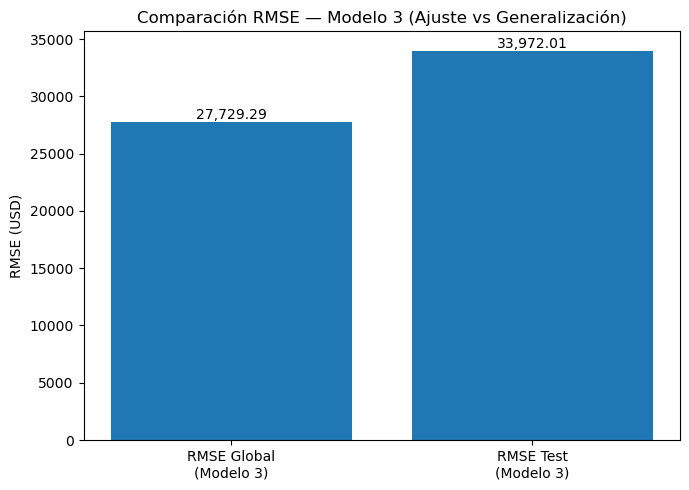

In [64]:
import matplotlib.pyplot as plt

# ============================================================
# COMPARACIÓN FINAL — RMSE GLOBAL vs RMSE TEST (MODELO 3)
# ============================================================

etiquetas = ["RMSE Global\n(Modelo 3)", "RMSE Test\n(Modelo 3)"]
valores = [RMSE_m3, RMSE_test_m3]

plt.figure(figsize=(7,5))

barras = plt.bar(etiquetas, valores)

plt.ylabel("RMSE (USD)")
plt.title("Comparación RMSE — Modelo 3 (Ajuste vs Generalización)")

# Mostrar valores arriba de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:,.2f}",
        ha='center',
        va='bottom'
    )

plt.grid(False)
plt.tight_layout()
plt.show()
